# Figure 4

This notebook prepares and visualises the empirical-landscape ruggedness analyses for Figure 4. It reads shared empirical decay products generated elsewhere, generates Figure-4-specific raw products when needed, writes Figure-4-specific processed payloads into `processed_data/`, and saves the composed figure into `figures/pdf/`, `figures/png/`, and `figures/eps/`.


## Setup

Load the empirical-landscape, decay-fitting, and plotting tools used by the standalone Figure 4 workflow.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from collections.abc import Callable

import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.legend_handler import HandlerTuple
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

from slide.data_generation import (
    EMPIRICAL_NAMES,
    all_start_locs,
    generate_empirical_decay_curves,
    load_empirical_landscape,
    nk_uniform_start_locs,
    run_nk_start_averaged_diffusion,
    uniform_start_locs,
)
from slide.direvo_functions import get_single_decay_rate_IK_v2
from slide.ruggedness_functions import (
    find_distance_to_closest_max,
    get_dirichlet_metric,
    get_landscape_spectrum,
    get_mean_paths_to_max,
    get_spectral_entropy,
    landscape_r2,
    local_epistasis,
    max_possible_paths,
    roughness_to_slope,
)
from slide.utils import (
    FIGURE_COLORS,
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
SAVE_TYPE_LIST = ("pdf", "png", "eps")
PANEL_DPI = 350

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
for figure_type in SAVE_TYPE_LIST:
    (FIGURES_DIR / figure_type).mkdir(parents=True, exist_ok=True)

print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")


def save_panel_figure(fig: plt.Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save an individual panel figure in every configured output format."""
    if not SAVE_FIGURES:
        return
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"{stem}.{figure_type}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: plt.Axes, letter: str) -> None:
    """Add the panel letter annotation used in the paper figures."""
    ax.text(-0.16, 1.08, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")


raw_data: /home/idris/workspace_python/SLIDE/raw_data
processed_data: /home/idris/workspace_python/SLIDE/processed_data
figures: /home/idris/workspace_python/SLIDE/figures


## Figure 4 Files And Parameters

Define the raw products consumed by Figure 4 and the Figure-4-specific processed filenames. Large all-start empirical diffusion simulations are still expected to exist in `raw_data/`; the Figure-4-only NK heterogeneity product is generated in this notebook.


In [2]:
RAW_FILES = {
    "nk_heterogeneity": "figure4_nk_heterogeneity_raw.pkl",
    **{
        f"empirical_decay_{name}_all": f"figure4_empirical_decay_{name}_all_raw.pkl"
        for name in EMPIRICAL_NAMES
    },
    **{
        f"empirical_decay_{name}_popsize": f"figure4_empirical_decay_{name}_popsize_raw.pkl"
        for name in EMPIRICAL_NAMES
    },
}

PROCESSED_FILES = {
    "spectra": "figure4_empirical_fourier_spectra_processed.pkl",
    "local_rho": "figure4_local_rho_processed.pkl",
    "replicate_variability": "figure4_replicate_variability_processed.pkl",
    "subsampling": "figure4_subsampling_processed.pkl",
    "popsize": "figure4_popsize_processed.pkl",
    "generation_count": "figure4_generation_count_processed.pkl",
    "metric_comparison": "figure4_metric_comparison_processed.pkl",
}

# Processing controls. Set MAX_LOCAL_STARTS to an integer for a quick smoke run;
# use None for the full all-start Figure 4B calculation.
MAX_LOCAL_STARTS: int | None = None
REPLICATE_VARIABILITY_BOOTSTRAPS = 250
SUBSAMPLING_BOOTSTRAPS = 1000
SUBSAMPLING_POINTS = 11
GENERATION_COUNT_BOOTSTRAPS = 250
POPSIZE_BOOTSTRAPS = 250
BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES = 10000
PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES = 500
BOOTSTRAP_SEED = 42
MUTATION_RATE = 0.1
FIGURE4_DE_PROCESSING_STEPS = 25
EPS = 1e-8

labels = ["GB1", "TrpB", "TEV", "ParD3"]
colours = ["tab:orange", "tab:blue", "tab:green", "#f55f74"]
markers = ["o", "s", "^", "D"]
c_reference = FIGURE_COLORS["reference"]
empirical_styles = {
    name: {"color": color, "marker": marker}
    for name, color, marker in zip(EMPIRICAL_NAMES, colours, markers)
}
nk_colours = ["#111111", "#444444", "#777777", "#aaaaaa"]
nk_markers = ["o", "s", "^", "D"]

print("Figure 4 raw products:")
for key, filename in RAW_FILES.items():
    print(f"  {key}: {RAW_DATA_DIR / filename}")


Figure 4 raw products:
  nk_heterogeneity: /home/idris/workspace_python/SLIDE/raw_data/figure4_nk_heterogeneity_raw.pkl
  empirical_decay_GB1_all: /home/idris/workspace_python/SLIDE/raw_data/figure4_empirical_decay_GB1_all_raw.pkl
  empirical_decay_TrpB_all: /home/idris/workspace_python/SLIDE/raw_data/figure4_empirical_decay_TrpB_all_raw.pkl
  empirical_decay_TEV_all: /home/idris/workspace_python/SLIDE/raw_data/figure4_empirical_decay_TEV_all_raw.pkl
  empirical_decay_ParD3_all: /home/idris/workspace_python/SLIDE/raw_data/figure4_empirical_decay_ParD3_all_raw.pkl
  empirical_decay_GB1_popsize: /home/idris/workspace_python/SLIDE/raw_data/figure4_empirical_decay_GB1_popsize_raw.pkl
  empirical_decay_TrpB_popsize: /home/idris/workspace_python/SLIDE/raw_data/figure4_empirical_decay_TrpB_popsize_raw.pkl
  empirical_decay_TEV_popsize: /home/idris/workspace_python/SLIDE/raw_data/figure4_empirical_decay_TEV_popsize_raw.pkl
  empirical_decay_ParD3_popsize: /home/idris/workspace_python/SLIDE/raw

## Processing Helpers

These small helpers keep the Figure 4 cells readable while preserving the raw array conventions used in the paper pipeline. They accept both raw trajectories that still contain population-level fitness values and newer raw trajectories that already store mean population fitness.


In [3]:
def raw_path(key: str) -> Path:
    """Return the raw-data path for a Figure 4 payload key.

    Parameters:
    - key: str
        Figure 4 raw payload key in ``RAW_FILES``.

    Returns:
    - Path
        Full path to the requested raw payload.
    """

    return RAW_DATA_DIR / RAW_FILES[key]


def processed_path(key: str) -> Path:
    """Return the processed-data path for a Figure 4 payload key."""
    return PROCESSED_DATA_DIR / PROCESSED_FILES[key]


def load_or_build_processed(key: str, builder: Callable[[], dict[str, object]]) -> dict[str, object]:
    """Load a processed Figure 4 payload or build and save it.

    Parameters:
    - key: str
        Figure 4 processed payload key in ``PROCESSED_FILES``.
    - builder: Callable[[], dict[str, object]]
        Function that builds the processed payload when rebuilding is allowed.

    Returns:
    - dict[str, object]
        Processed payload for plotting or downstream processing.
    """
    path = processed_path(key)
    if path.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
        print(f"Loaded {path.name}")
        return load_pickle(path)
    if PLOT_ONLY:
        raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {path}")
    payload = builder()
    save_pickle(payload, path)
    print(f"Saved {path.name}")
    return payload


def as_start_rep_curves(decay: np.ndarray) -> np.ndarray:
    """Return empirical decay curves indexed by start, replicate, and generation."""
    arr = np.asarray(decay)
    if arr.ndim == 3:
        return arr.astype(float)
    if arr.ndim == 4:
        return arr.mean(axis=2).astype(float)
    raise ValueError(f"Expected 3D or 4D empirical decay array, got shape {arr.shape}")


def as_popsize_start_rep_curves(decay: np.ndarray) -> np.ndarray:
    """Return empirical pop-size decay curves indexed by pop size, start, replicate, and generation."""
    arr = np.asarray(decay)
    if arr.ndim == 4:
        return arr.astype(float)
    if arr.ndim == 5:
        return arr.mean(axis=3).astype(float)
    raise ValueError(f"Expected 4D or 5D empirical popsize decay array, got shape {arr.shape}")


def fit_rho2_from_gmu(g_mu: np.ndarray, *, steps: int | None = None, mutation_rate: float = MUTATION_RATE) -> float:
    """Fit rho2 from a squared-fitness decay curve."""
    curve = np.asarray(g_mu, dtype=float)
    if steps is not None:
        curve = curve[: int(steps)]
    if curve.size < 3 or not np.all(np.isfinite(curve)):
        return np.nan
    denom = max(abs(float(curve[0])), EPS)
    normalized = np.clip(curve / denom, EPS, None)
    try:
        return float(get_single_decay_rate_IK_v2(normalized, mut=mutation_rate, num_steps=len(normalized), fix_amplitude=True)[0] / 2)
    except Exception:
        return np.nan


def fit_rho2_from_fmu(f_mu: np.ndarray, *, steps: int | None = None, mutation_rate: float = MUTATION_RATE) -> float:
    """Fit rho2 by squaring a mean-fitness decay curve before fitting."""
    curve = np.asarray(f_mu, dtype=float)
    if steps is not None:
        curve = curve[: int(steps)]
    return fit_rho2_from_gmu(curve**2, mutation_rate=mutation_rate)


def finite_array(values: np.ndarray) -> np.ndarray:
    """Return the finite entries of a numeric array."""
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


## Figure 4 Raw Products

Generate Figure 4-specific raw products that are not produced by Figure 3.


In [4]:
nk_heterogeneity_path = raw_path("nk_heterogeneity")

N, A = 4, 20
K_values = list(range(N))
mutation_rate = 0.1
popsize = 1200
num_starts = 10000
start_batch_size = 1000
assert num_starts % start_batch_size == 0, "Implementation below requires num_start to be a multiple of start_batch_size"
num_reps = 10
M = 25
seed = 42

if PLOT_ONLY:
    print("PLOT_ONLY=True: skipping Figure 4 NK raw product loading/building")
elif nk_heterogeneity_path.exists() and not OVERWRITE_RAW_PKL:
    print(f"Loaded {nk_heterogeneity_path.name}")
    nk_heterogeneity_payload = load_pickle(nk_heterogeneity_path)
else:
    starts = nk_uniform_start_locs(n_sites=N, num_alleles=A, num_starts=num_starts)
    nk_keys = jr.split(jr.PRNGKey(seed), len(K_values))
    nk_heterogeneity = []
    for key, K in tqdm(list(zip(nk_keys, K_values)), desc="Figure 4 NK heterogeneity"):
        k_curves = []
        start_batches = [
            starts[i : i + start_batch_size]
            for i in range(0, num_starts, start_batch_size)
        ]
        batch_keys = jr.split(jr.fold_in(key, 20_000), len(start_batches))
        for start_batch, batch_key in tqdm(list(zip(start_batches, batch_keys)), desc=f"K={K} start batches", leave=False):
            k_curves.append(
                run_nk_start_averaged_diffusion(
                    rng_key=key,
                    trajectory_rng_key=batch_key,
                    n_sites=N,
                    k=int(K),
                    num_alleles=A,
                    starts=start_batch,
                    popsize=popsize,
                    mutation_rate_per_site=mutation_rate / N,
                    num_reps_per_start=num_reps,
                    num_steps=M,
                )
            )
        nk_heterogeneity.append(np.concatenate(k_curves, axis=0))
    nk_heterogeneity_payload = {
        "data": np.asarray(nk_heterogeneity),
        "params": {
            "N": N,
            "A": A,
            "K_values": K_values,
            "mutation_rate": mutation_rate,
            "per_site_mutation_rate": mutation_rate / N,
            "popsize": popsize,
            "num_starts": num_starts,
            "start_batch_size": start_batch_size,
            "num_reps_per_start": num_reps,
            "M": M,
            "seed": seed,
        },
        "metadata": {
            "description": "N4A20 NK heterogeneity start-averaged decay curves.",
            "paper_reference": "Figure 4B",
            "output_key": "figure4_nk_heterogeneity",
            "filename": RAW_FILES["nk_heterogeneity"],
            "shape": "K, start, generation",
        },
    }
    save_pickle(nk_heterogeneity_payload, nk_heterogeneity_path)
    print(f"Saved {nk_heterogeneity_path.name}")


PLOT_ONLY=True: skipping Figure 4 NK raw product loading/building


## Figure 4 Empirical Raw Products

Generate or load the empirical all-start and population-size no-selection decay products used by Figure 4. These products are Figure-4 local and are saved with `figure4_...` raw filenames.


In [5]:
landscapes = {} if PLOT_ONLY else {name: load_empirical_landscape(name) for name in EMPIRICAL_NAMES}

empirical_mutation_rate = 0.1
empirical_num_reps = 10
empirical_M = 40
empirical_seed = 42
pop_sizes = np.unique(np.concatenate([np.linspace(25, 3000, 10, dtype=int), [1200]])).astype(int)
reference_pop_sizes = {"GB1": 2338, "TrpB": 2338, "TEV": 2338, "ParD3": 1200}

empirical_raw_names = () if PLOT_ONLY else EMPIRICAL_NAMES
if PLOT_ONLY:
    print("PLOT_ONLY=True: skipping Figure 4 empirical raw product loading/building")

empirical_all_payloads = {}
for name in tqdm(empirical_raw_names, desc="Figure 4 empirical all-start decay"):
    all_decay_path = raw_path(f"empirical_decay_{name}_all")
    if all_decay_path.exists() and not OVERWRITE_RAW_PKL:
        print(f"Loaded {all_decay_path.name}")
        empirical_all_payloads[name] = load_pickle(all_decay_path)
        continue

    landscape = landscapes[name]
    nominal_popsize = int(reference_pop_sizes[name])
    effective_popsize = max(1, int(nominal_popsize / 20)) if name == "ParD3" else nominal_popsize
    per_site_mutation_rate = empirical_mutation_rate / landscape.ndim
    starts = all_start_locs(landscape)
    all_decay = generate_empirical_decay_curves(
        landscape,
        mutation_rate=per_site_mutation_rate,
        popsize=effective_popsize,
        starts=starts,
        num_reps=empirical_num_reps,
        num_steps=empirical_M,
        seed=empirical_seed,
    )
    empirical_all_payloads[name] = {
        "data": all_decay,
        "params": {
            "name": name,
            "mutation_rate": empirical_mutation_rate,
            "per_site_mutation_rate": per_site_mutation_rate,
            "popsize": nominal_popsize,
            "effective_popsize": effective_popsize,
            "starts_count": int(landscape.size),
            "start_policy": "all",
            "num_reps": empirical_num_reps,
            "M": empirical_M,
            "seed": empirical_seed,
        },
        "metadata": {
            "description": f"{name} all-start empirical no-selection decay curves for Figure 4.",
            "paper_reference": "Figure 4",
            "output_key": f"figure4_empirical_decay_{name}_all",
            "filename": RAW_FILES[f"empirical_decay_{name}_all"],
            "shape": "start, replicate, generation",
        },
    }
    save_pickle(empirical_all_payloads[name], all_decay_path)
    print(f"Saved {all_decay_path.name}")

empirical_popsize_payloads = {}
for name in tqdm(empirical_raw_names, desc="Figure 4 empirical popsize decay"):
    popsize_decay_path = raw_path(f"empirical_decay_{name}_popsize")
    if popsize_decay_path.exists() and not OVERWRITE_RAW_PKL:
        print(f"Loaded {popsize_decay_path.name}")
        empirical_popsize_payloads[name] = load_pickle(popsize_decay_path)
        continue

    landscape = landscapes[name]
    starts_count = int(landscape.size)
    starts = all_start_locs(landscape)
    effective_pop_sizes = [max(1, int(popsize / 20)) if name == "ParD3" else int(popsize) for popsize in pop_sizes]
    popsize_results = np.empty((len(pop_sizes), starts_count, empirical_num_reps, empirical_M), dtype=np.float32)
    for pop_index, (nominal_popsize, effective_popsize) in enumerate(tqdm(
        list(zip(pop_sizes, effective_pop_sizes)),
        desc=f"{name} popsize decay",
        leave=False,
    )):
        popsize_results[pop_index] = generate_empirical_decay_curves(
            landscape,
            mutation_rate=empirical_mutation_rate / landscape.ndim,
            popsize=effective_popsize,
            starts=starts,
            num_reps=empirical_num_reps,
            num_steps=empirical_M,
            seed=empirical_seed,
        )

    empirical_popsize_payloads[name] = {
        "data": popsize_results,
        "params": {
            "name": name,
            "mutation_rate": empirical_mutation_rate,
            "per_site_mutation_rate": empirical_mutation_rate / landscape.ndim,
            "pop_sizes": pop_sizes,
            "effective_pop_sizes": effective_pop_sizes,
            "starts_count": starts_count,
            "start_policy": "all",
            "num_reps": empirical_num_reps,
            "M": empirical_M,
            "seed": empirical_seed,
        },
        "metadata": {
            "description": f"{name} empirical population-size no-selection decay sweep for Figure 4E.",
            "paper_reference": "Figure 4E",
            "output_key": f"figure4_empirical_decay_{name}_popsize",
            "filename": RAW_FILES[f"empirical_decay_{name}_popsize"],
            "shape": "population_size, start, replicate, generation",
        },
    }
    save_pickle(empirical_popsize_payloads[name], popsize_decay_path)
    print(f"Saved {popsize_decay_path.name}")

if not PLOT_ONLY:
    empirical_all_curves = {
        name: as_start_rep_curves(payload["data"])
        for name, payload in empirical_all_payloads.items()
    }
    empirical_popsize_curves = {
        name: as_popsize_start_rep_curves(payload["data"])
        for name, payload in empirical_popsize_payloads.items()
    }
    nk_heterogeneity_curves = np.asarray(nk_heterogeneity_payload["data"], dtype=float)
    nk_heterogeneity_params = nk_heterogeneity_payload["params"]
    nk_k_values = np.asarray(nk_heterogeneity_params["K_values"], dtype=int)
    nk_rho_values = (nk_k_values + 1) / float(nk_heterogeneity_params["N"])

    for name in EMPIRICAL_NAMES:
        print(name, "all-start", empirical_all_curves[name].shape, "popsize", empirical_popsize_curves[name].shape)
    print("NK heterogeneity", nk_heterogeneity_curves.shape, "K", nk_k_values, "rho_NK", nk_rho_values)


PLOT_ONLY=True: skipping Figure 4 empirical raw product loading/building


Figure 4 empirical all-start decay: 0it [00:00, ?it/s]

Figure 4 empirical popsize decay: 0it [00:00, ?it/s]

## Panel A Processing

Compute collapsed Fourier spectra for the complete empirical landscapes. The analytical `rho_2` value is the Fourier-power weighted spectral centroid; ParD3 uses `N=3`, while GB1, TrpB, and TEV use `N=4`.


In [6]:
def build_spectra_payload() -> dict[str, object]:
    spectra = [
        get_landscape_spectrum(landscapes[name], remove_constant=False, on_gpu=False, norm=False)
        for name in EMPIRICAL_NAMES
    ]
    A = 20
    dimensions = np.array([landscapes[name].ndim for name in EMPIRICAL_NAMES], dtype=int)
    rho2_dirichlet = np.asarray([
        float(get_dirichlet_metric(landscapes[name], on_gpu=False))
        for name in EMPIRICAL_NAMES
    ])
    frequency_centroids = rho2_dirichlet * dimensions * (A - 1) / A
    return {
        "data": {
            "spectra": spectra,
            "rho2_dirichlet": rho2_dirichlet,
            "frequency_centroids": frequency_centroids,
            "dimensions": dimensions,
            "A": A,
            "labels": labels,
        },
        "metadata": {"paper_reference": "Figure 4A", "description": "Empirical Fourier spectra and analytical rho2 values."},
    }

spectra_payload = load_or_build_processed("spectra", build_spectra_payload)
spectra_data = spectra_payload["data"]
rho2_dirichlet_vals = np.asarray(spectra_data["rho2_dirichlet"])
rho2_dirichlet_vals


Loaded figure4_empirical_fourier_spectra_processed.pkl


array([0.59757441, 0.60176361, 0.94421089, 0.42257887])

### Panel A Individual Export
This cell saves the annotated Figure 4A subfigure after the empirical Fourier spectra have been processed.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


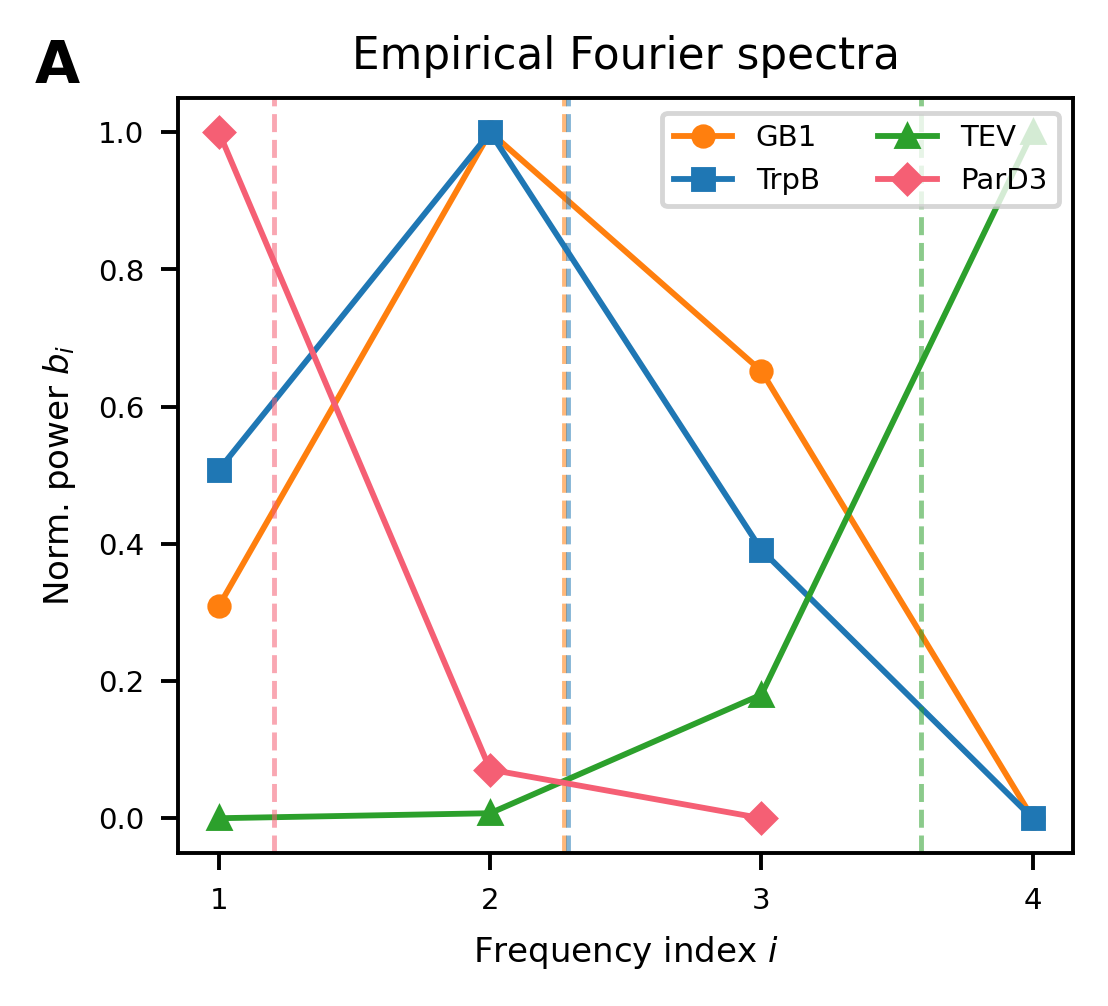

In [7]:
fig, ax = plt.subplots(figsize=(3.3, 2.8), dpi=PANEL_DPI)
for n, spectrum in enumerate(spectra_data["spectra"]):
    nonconstant = np.asarray(spectrum, dtype=float)[1:]
    spectrum_norm = (nonconstant - nonconstant.min()) / (nonconstant.max() - nonconstant.min() + EPS)
    indexes = np.arange(1, len(nonconstant) + 1)
    ax.plot(indexes, spectrum_norm, marker=markers[n], markersize=4, linewidth=1.2, color=colours[n], label=labels[n])
    ax.axvline(spectra_data["frequency_centroids"][n], color=colours[n], linestyle="--", alpha=0.55, linewidth=1)
ax.set_title("Empirical Fourier spectra", fontsize=FIGURE_TITLE_SIZE)
ax.set_xlabel(r"Frequency index $i$", fontsize=FIGURE_LABEL_SIZE)
ax.set_ylabel(r"Norm. power $b_i$", fontsize=FIGURE_LABEL_SIZE)
ax.set_xticks([1, 2, 3, 4])
ax.tick_params(axis="both", labelsize=FIGURE_TICK_SIZE)
ax.legend(fontsize=FIGURE_LEGEND_SIZE, frameon=True, loc="upper right", ncol=2)
add_panel_letter(ax, "A")
save_panel_figure(fig, "figure_4A")
plt.show()


## Panel B Processing

Fit local squared-decay estimates from individual starting points. Each starting point is represented by its replicate-averaged mutation-only decay curve.


In [8]:
def build_local_rho_payload() -> dict[str, object]:
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    empirical_local_rhos = {}
    used_start_indices = {}
    for name in EMPIRICAL_NAMES:
        curves = empirical_all_curves[name]
        start_curves = curves.mean(axis=1)
        if MAX_LOCAL_STARTS is None or MAX_LOCAL_STARTS >= start_curves.shape[0]:
            indices = np.arange(start_curves.shape[0])
        else:
            indices = np.sort(rng.choice(start_curves.shape[0], size=MAX_LOCAL_STARTS, replace=False))
        vals = [
            fit_rho2_from_fmu(start_curves[idx], steps=start_curves.shape[-1])
            for idx in tqdm(indices, desc=f"{name} local rho2")
        ]
        empirical_local_rhos[name] = finite_array(vals)
        used_start_indices[name] = indices

    nk_local_rhos = {}
    for rho_nk, k_value, curves in zip(nk_rho_values, nk_k_values, nk_heterogeneity_curves):
        start_curves = np.asarray(curves, dtype=float)
        if MAX_LOCAL_STARTS is None or MAX_LOCAL_STARTS >= start_curves.shape[0]:
            indices = np.arange(start_curves.shape[0])
        else:
            indices = np.sort(rng.choice(start_curves.shape[0], size=MAX_LOCAL_STARTS, replace=False))
        vals = [
            fit_rho2_from_fmu(start_curves[idx], steps=start_curves.shape[-1])
            for idx in tqdm(indices, desc=f"NK K={k_value} local rho2")
        ]
        nk_local_rhos[float(rho_nk)] = finite_array(vals)

    return {
        "data": {
            "empirical_local_rhos": empirical_local_rhos,
            "nk_local_rhos": nk_local_rhos,
            "used_start_indices": used_start_indices,
            "nk_k_values": nk_k_values,
            "nk_rho_values": nk_rho_values,
        },
        "metadata": {"paper_reference": "Figure 4B", "description": "Local fitted rho2 estimates for NK and empirical starting genotypes."},
    }

local_rho_payload = load_or_build_processed("local_rho", build_local_rho_payload)
local_rho_data = local_rho_payload["data"]
empirical_local_rhos = local_rho_data["empirical_local_rhos"]
nk_local_rhos = local_rho_data["nk_local_rhos"]
local_rhos = empirical_local_rhos
{name: values.shape for name, values in empirical_local_rhos.items()}, {rho: values.shape for rho, values in nk_local_rhos.items()}


Loaded figure4_local_rho_processed.pkl


({'GB1': (160000,), 'TrpB': (160000,), 'TEV': (160000,), 'ParD3': (8000,)},
 {0.25: (10000,), 0.5: (10000,), 0.75: (10000,), 1.0: (10000,)})

### Panel B Individual Export
This cell saves the annotated Figure 4B subfigure after the local ruggedness estimates have been processed.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


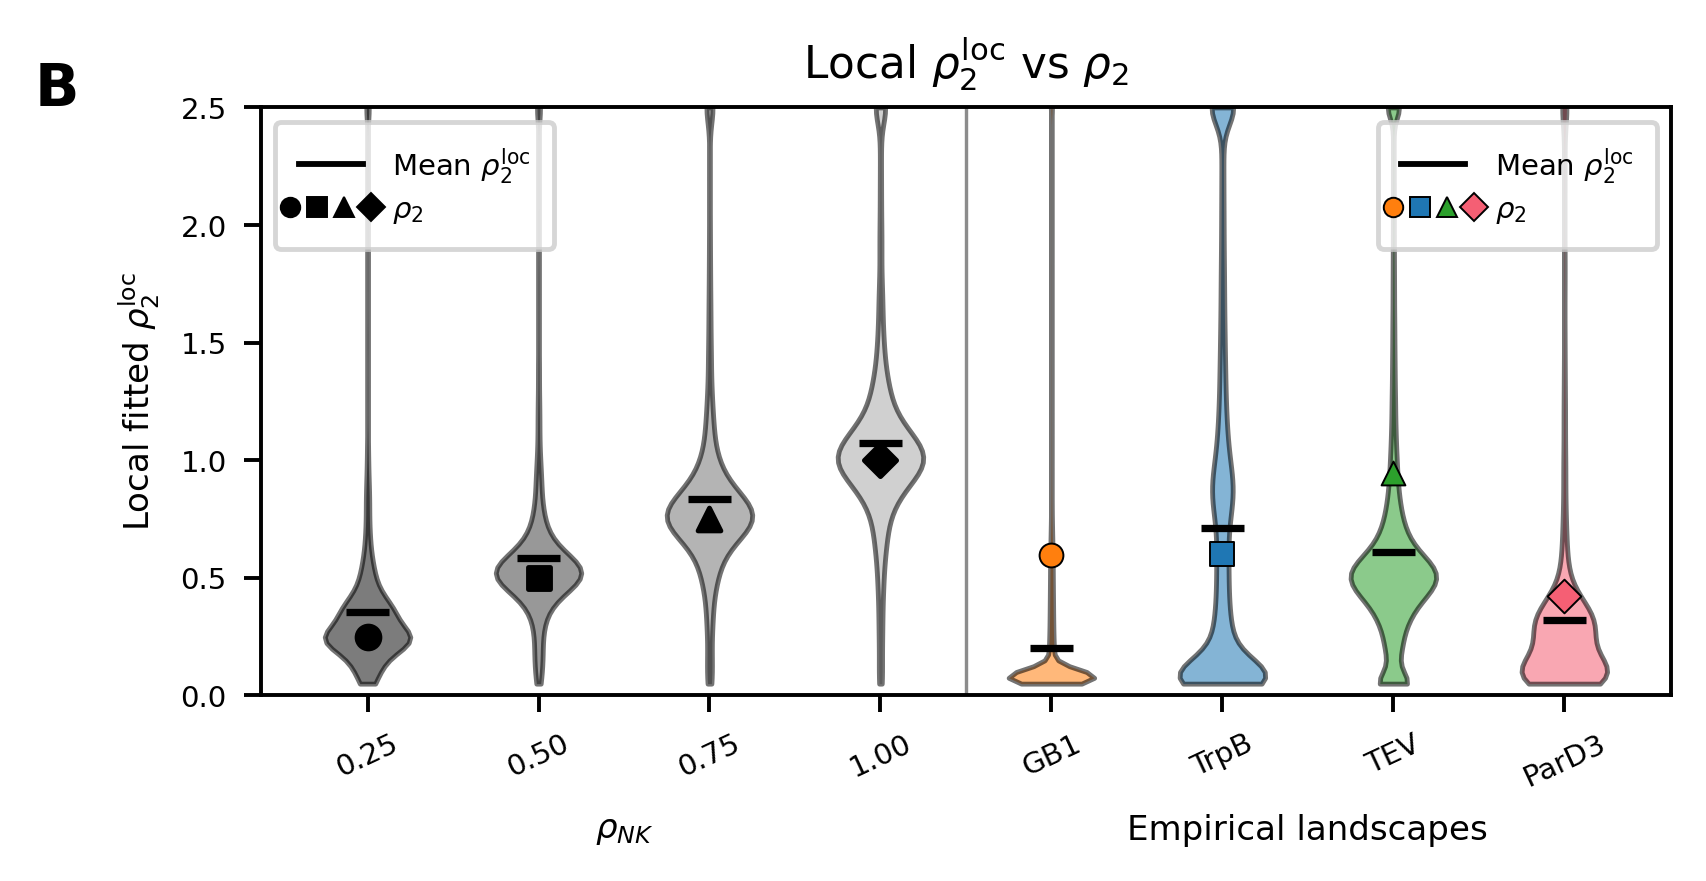

In [9]:
nk_local_items = [(float(rho), finite_array(values)) for rho, values in sorted(nk_local_rhos.items())]
empirical_local_items = [(name, finite_array(empirical_local_rhos[name])) for name in EMPIRICAL_NAMES]
local_data = [values for _, values in nk_local_items] + [values for _, values in empirical_local_items]
positions = np.arange(1, len(local_data) + 1)
fig, ax = plt.subplots(figsize=(5.2, 2.8), dpi=PANEL_DPI)
vp = ax.violinplot(local_data, positions=positions, showmeans=True, showextrema=False)
body_colours = nk_colours[: len(nk_local_items)] + colours
for body, color in zip(vp["bodies"], body_colours):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.55)
vp["cmeans"].set_color("black")
for idx, (rho_nk, _) in enumerate(nk_local_items, start=1):
    ax.scatter(idx, rho_nk, color="black", marker=nk_markers[idx - 1], s=22, zorder=3)
for idx, value in enumerate(rho2_dirichlet_vals, start=len(nk_local_items) + 1):
    ax.scatter(idx, value, color=colours[idx - len(nk_local_items) - 1], marker=markers[idx - len(nk_local_items) - 1], s=24, edgecolors="black", linewidth=0.4, zorder=3)
group_boundary = len(nk_local_items) + 0.5
ax.axvline(group_boundary, color="black", linewidth=0.7, alpha=0.45)
xtick_labels = [rf"{rho:.2f}" for rho, _ in nk_local_items] + labels
ax.set_xticks(positions)
ax.set_xticklabels(xtick_labels, rotation=25, ha="center", fontsize=FIGURE_TICK_SIZE)
ax.text(np.mean(positions[: len(nk_local_items)]), -0.2, r"$\rho_{NK}$", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=FIGURE_LABEL_SIZE)
ax.text(np.mean(positions[len(nk_local_items) :]), -0.2, "Empirical landscapes", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=FIGURE_LABEL_SIZE)
ax.set_ylabel(r"Local fitted $\rho^{\mathrm{loc}}_2$", fontsize=FIGURE_LABEL_SIZE)
ax.set_title(r"Local $\rho^{\mathrm{loc}}_2$ vs $\rho_2$", fontsize=FIGURE_TITLE_SIZE)
ax.tick_params(axis="y", labelsize=FIGURE_TICK_SIZE)
ax.set_ylim(0,2.5)
nk_rho_handles = tuple(
    Line2D([0], [0], marker=marker, linestyle="None", markerfacecolor="black", markeredgecolor="black", markeredgewidth=0.4, markersize=4)
    for marker in nk_markers[: len(nk_local_items)]
)
mean_rho_handle = Line2D([0], [0], color="black", linewidth=1.2, label=r"Mean $\rho^{\mathrm{loc}}_2$")
rho2_handles = tuple(
    Line2D([0], [0], marker=marker, linestyle="None", markerfacecolor=color, markeredgecolor="black", markeredgewidth=0.4, markersize=4)
    for marker, color in zip(markers, colours)
)
nk_legend = ax.legend(
    handles=[mean_rho_handle, nk_rho_handles],
    labels=[r"Mean $\rho^{\mathrm{loc}}_2$", r"$\rho_2$"],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=1.5)},
    handlelength=2.2,
    handletextpad=1,
    fontsize=FIGURE_LEGEND_SIZE,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.35,
    loc="upper left",
)
ax.add_artist(nk_legend)
ax.legend(
    handles=[mean_rho_handle, rho2_handles],
    labels=[r"Mean $\rho^{\mathrm{loc}}_2$", r"$\rho_2$"],
    handler_map={tuple: HandlerTuple(ndivide=4, pad=1.5)},
    handlelength=2.2,
    handletextpad=1,
    fontsize=FIGURE_LEGEND_SIZE,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.35,
    loc="upper right",
)
fig.subplots_adjust(bottom=0.28)
add_panel_letter(ax, "B")
save_panel_figure(fig, "figure_4B")
plt.show()


## Panel C Processing

Estimate uncertainty from repeated measurements with 10 starting genotypes. For each bootstrap draw, the same starting genotypes are reused across five replicate estimates, and the standard deviation across those estimates is recorded.


In [10]:
def build_replicate_variability_payload() -> dict[str, object]:
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    variability = {}
    for name in EMPIRICAL_NAMES:
        curves = empirical_all_curves[name]
        n_starts, n_reps, n_steps = curves.shape
        boot_stds = []
        starts_per_boot = min(10, n_starts)
        reps_per_boot = min(5, n_reps)
        for _ in tqdm(range(REPLICATE_VARIABILITY_BOOTSTRAPS), desc=f"{name} replicate variability"):
            start_idx = rng.choice(n_starts, size=starts_per_boot, replace=False)
            rep_idx = rng.choice(n_reps, size=reps_per_boot, replace=False)
            estimates = []
            for rep in rep_idx:
                f_mu_by_start = curves[start_idx, rep, :]
                g_mu = (f_mu_by_start ** 2).mean(axis=0)
                estimates.append(fit_rho2_from_gmu(g_mu, steps=n_steps))
            estimates = finite_array(estimates)
            if estimates.size:
                boot_stds.append(float(np.std(estimates)))
        variability[name] = finite_array(boot_stds)
    return {
        "data": {"variability": variability, "starts_per_boot": 10, "replicates_per_boot": 5},
        "metadata": {"paper_reference": "Figure 4C", "description": "Bootstrap standard deviation of fitted rho2 estimates using start-level squared curves."},
    }

replicate_variability_payload = load_or_build_processed("replicate_variability", build_replicate_variability_payload)
replicate_variability = replicate_variability_payload["data"]["variability"]
{name: values.shape for name, values in replicate_variability.items()}


Loaded figure4_replicate_variability_processed.pkl


{'GB1': (250,), 'TrpB': (250,), 'TEV': (250,), 'ParD3': (250,)}

### Panel C Individual Export
This cell saves the annotated Figure 4C subfigure after the replicate uncertainty summary has been processed.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


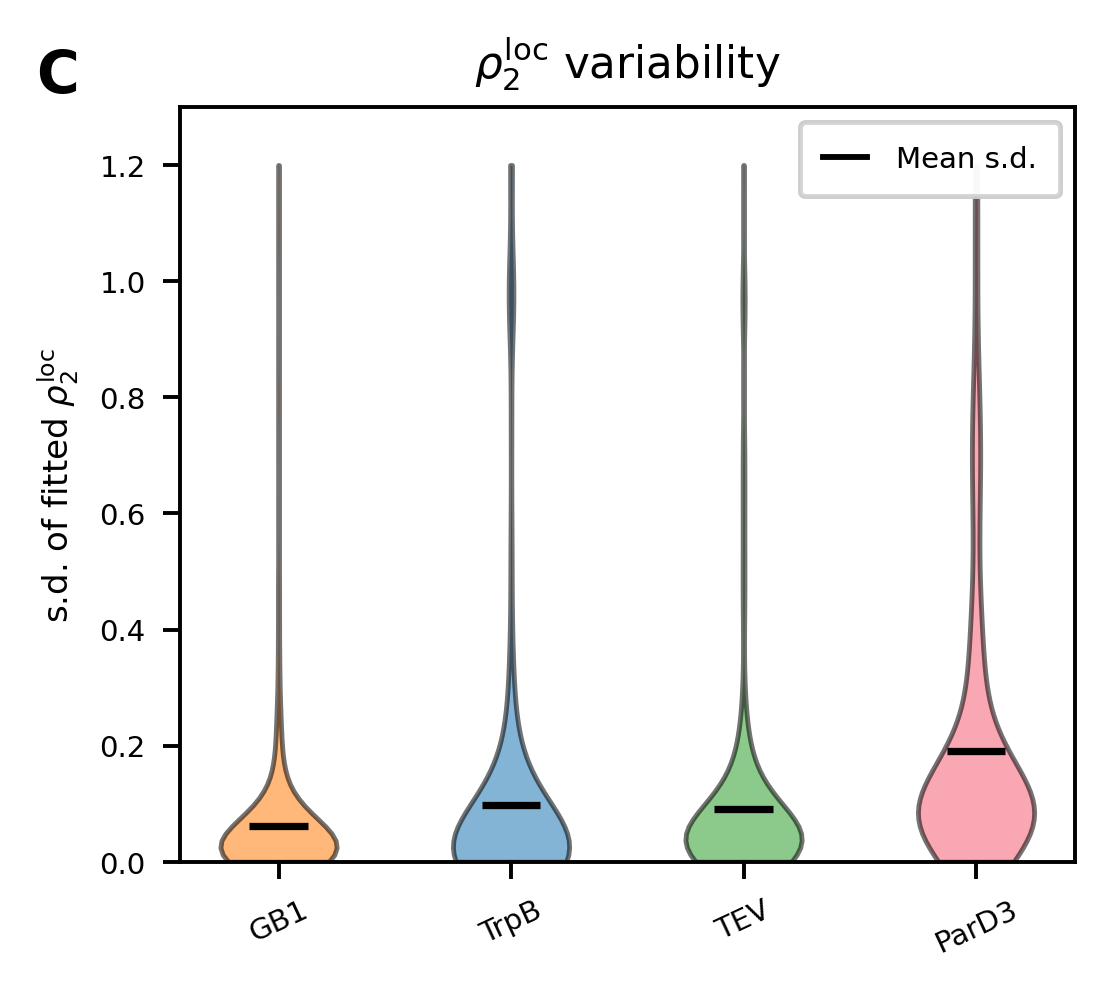

In [11]:
variability_data = [finite_array(replicate_variability[name]) for name in EMPIRICAL_NAMES]
fig, ax = plt.subplots(figsize=(3.3, 2.8), dpi=PANEL_DPI)
vp = ax.violinplot(variability_data, showmeans=True, showextrema=False)
for body, color in zip(vp["bodies"], colours):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.55)
vp["cmeans"].set_color("black")
# for i, values in enumerate(variability_data, start=1):
#     ax.hlines(np.nanmean(values), i - 0.28, i + 0.28, colors="black", linewidth=1.2)
#     ax.scatter(i, np.nanmean(values), color=colours[i - 1], marker=markers[i - 1], s=24, edgecolors="black", linewidth=0.4, zorder=3)
ax.set_xticks(np.arange(1, len(EMPIRICAL_NAMES) + 1))
ax.set_xticklabels(labels, rotation=25, ha="center", fontsize=FIGURE_TICK_SIZE)
ax.set_ylabel(r"s.d. of fitted $\rho^{\mathrm{loc}}_2$", fontsize=FIGURE_LABEL_SIZE)
ax.set_title(r"$\rho^{\mathrm{loc}}_2$ variability", fontsize=FIGURE_TITLE_SIZE)
ax.tick_params(axis="y", labelsize=FIGURE_TICK_SIZE)
mean_rho_handle = Line2D([0], [0], color="black", linewidth=1.2, label=r"Mean $\rho^{\mathrm{loc}}_2$")
rho2_handles = tuple(
    Line2D([0], [0], marker=marker, linestyle="None", markerfacecolor=color, markeredgecolor="black", markeredgewidth=0.4, markersize=4)
    for marker, color in zip(markers, colours)
)
rhovar_legend = ax.legend(
    handles=[Line2D([0], [0], color="black", linewidth=1.2, label=r"Mean s.d.")],
    labels=[r"Mean s.d."],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=1.5)},
    handlelength=1.5,
    handletextpad=1,
    fontsize=FIGURE_LEGEND_SIZE,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.35,
    loc="upper right",
)
ax.set_ylim(0, 1.3)
ax.add_artist(rhovar_legend)
add_panel_letter(ax, "C")
save_panel_figure(fig, "figure_4C")
plt.show()


## Panel D Processing

Bootstrap global `rho_2` estimates while increasing the number of starting trajectories averaged. The largest count corresponds to the full empirical genotype space for each landscape.


In [12]:
def build_subsampling_payload() -> dict[str, object]:
    """Build Figure 4D starting-point subsampling estimates.

    Returns:
    - dict[str, object]
        Processed subsampling payload and trajectory-count metadata.
    """

    rng = np.random.default_rng(BOOTSTRAP_SEED)
    subsampling = {}
    trajectory_counts = {}
    for name in EMPIRICAL_NAMES:
        curves = empirical_all_curves[name]
        start_gmu = curves.mean(axis=1) ** 2
        counts = np.unique(
            np.concatenate(
                [
                    np.round(np.logspace(0, np.log10(start_gmu.shape[0]), SUBSAMPLING_POINTS)).astype(int),
                    [min(PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES if name == "ParD3" else BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, start_gmu.shape[0])],
                ]
            )
        )
        trajectory_counts[name] = counts
        landscape_results = []
        for count in tqdm(counts, desc=f"{name} subsampling"):
            boot_vals = []
            replace = count > start_gmu.shape[0]
            for _ in range(SUBSAMPLING_BOOTSTRAPS):
                idx = rng.choice(start_gmu.shape[0], size=int(count), replace=replace)
                g_mu = start_gmu[idx].mean(axis=0)
                boot_vals.append(fit_rho2_from_gmu(g_mu, steps=FIGURE4_DE_PROCESSING_STEPS))
            landscape_results.append(finite_array(boot_vals))
        subsampling[name] = landscape_results
    return {
        "data": {"subsampling": subsampling, "trajectory_counts": trajectory_counts},
        "metadata": {"paper_reference": "Figure 4D", "description": "Global fitted rho2 accuracy over sampled starting trajectories."},
    }

subsampling_payload = load_or_build_processed("subsampling", build_subsampling_payload)
subsampling_data = subsampling_payload["data"]["subsampling"]
trajectory_counts = subsampling_payload["data"]["trajectory_counts"]
figure_d_reference_rates = {}
figure_d_reference_means = {}
for name in EMPIRICAL_NAMES:
    counts = np.asarray(trajectory_counts[name])
    target_reference_count = PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES if name == "ParD3" else BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES
    reference_count = int(counts[counts <= target_reference_count].max())
    reference_index = int(np.where(counts == reference_count)[0][0])
    reference_rates = finite_array(subsampling_data[name][reference_index])
    figure_d_reference_rates[name] = reference_rates
    figure_d_reference_means[name] = float(np.nanmean(reference_rates))
{name: [len(v) for v in vals] for name, vals in subsampling_data.items()}


Loaded figure4_subsampling_processed.pkl


{'GB1': [1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000],
 'TrpB': [1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000],
 'TEV': [1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000],
 'ParD3': [1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000,
  1000]}

### Panel D Individual Export
This cell saves the annotated Figure 4D subfigure after the starting-point subsampling analysis has been processed.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


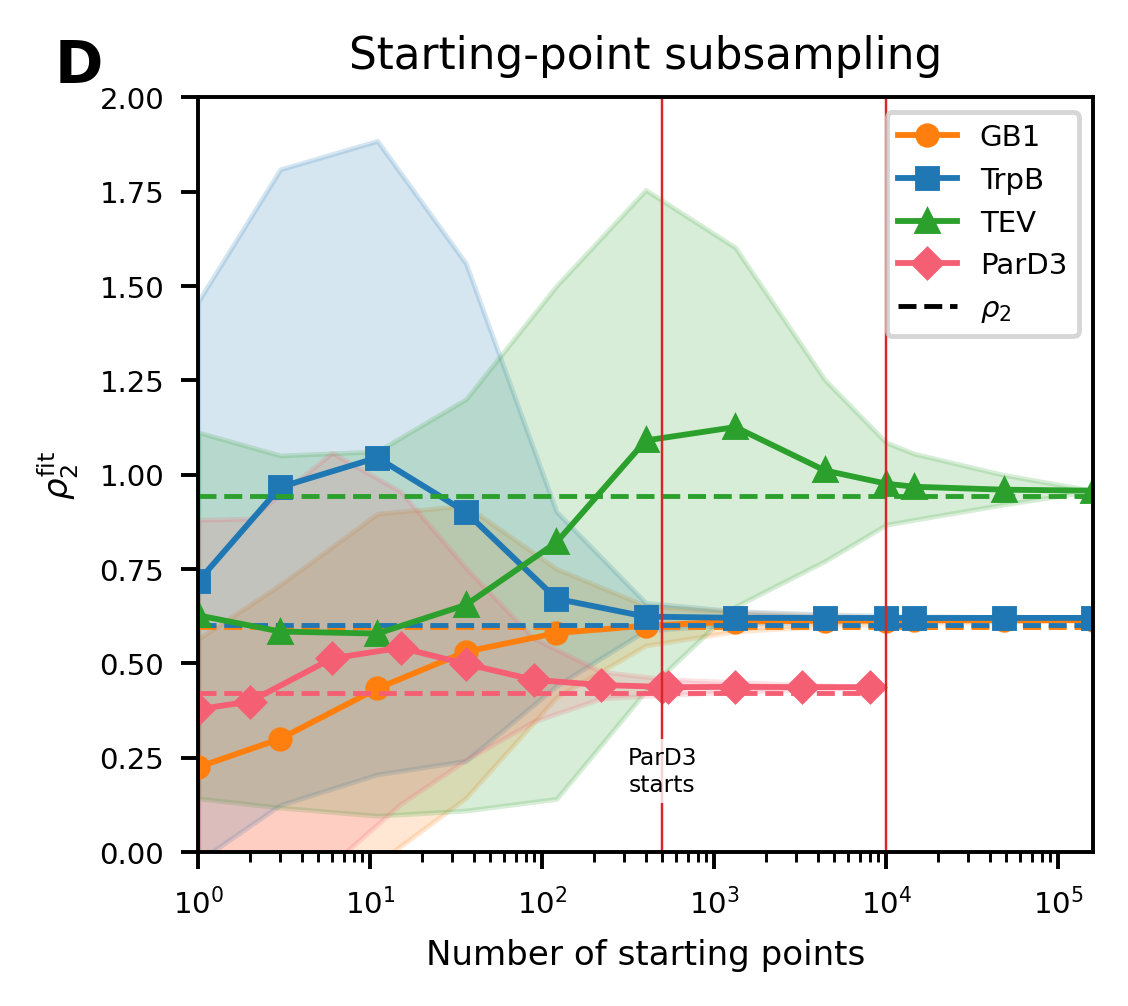

In [13]:
fig, ax = plt.subplots(figsize=(3.3, 2.8), dpi=PANEL_DPI)
for n, name in enumerate(EMPIRICAL_NAMES):
    counts = np.asarray(trajectory_counts[name])
    vals = subsampling_data[name]
    means = np.asarray([np.nanmean(v) for v in vals])
    stds = np.asarray([np.nanstd(v) for v in vals])
    ax.plot(counts, means, color=colours[n], marker=markers[n], markersize=4, linewidth=1.2, label=labels[n])
    ax.fill_between(counts, means - stds, means + stds, color=colours[n], alpha=0.18)
    ax.hlines(rho2_dirichlet_vals[n], xmin=counts.min(), xmax=counts.max(), color=colours[n], linestyle="--", linewidth=1)
ax.axvline(BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, color=c_reference, linewidth=0.5)
ax.axvline(PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, color=c_reference, linewidth=0.5)
ax.set_xscale("log")
ax.set_title(r"Starting-point subsampling", fontsize=FIGURE_TITLE_SIZE)
ax.set_xlabel("Number of starting points", fontsize=FIGURE_LABEL_SIZE)
ax.set_ylabel(r"$\rho_2^{\mathrm{fit}}$", fontsize=FIGURE_LABEL_SIZE)
ax.set_ylim(0, 2)
ax.set_xlim(1, 160000)
ax.tick_params(axis="both", labelsize=FIGURE_TICK_SIZE)
ax.text(PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, 0.28, "ParD3\nstarts", fontsize=FIGURE_TICK_SIZE*0.8, va="top", ha="center", bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
add_panel_letter(ax, "D")
rho2_handle = Line2D([0], [0], color="black", linewidth=1, linestyle="--", label=r"$\rho_2$")
handles_legend, labels_legend = ax.get_legend_handles_labels()
handles_legend.append(rho2_handle)
labels_legend.append(r"$\rho_2$")
ax.legend(handles=handles_legend, labels=labels_legend, fontsize=FIGURE_LEGEND_SIZE, frameon=True, loc="upper right", ncol=1)
save_panel_figure(fig, "figure_4D")
plt.show()


## Panel E Processing

Fit global squared-decay estimates across the empirical population-size sweep. Bootstrap intervals are computed over starting genotypes to show sampling variability.


In [14]:
def build_popsize_payload() -> dict[str, object]:
    """Build Figure 4E population-size sensitivity estimates.

    Returns:
    - dict[str, object]
        Processed population-size payload containing fitted rho2 bootstrap samples.
    """

    rng = np.random.default_rng(BOOTSTRAP_SEED)
    popsize_results = {}
    for name in EMPIRICAL_NAMES:
        curves_by_pop = empirical_popsize_curves[name]
        raw_params = empirical_popsize_payloads[name]["params"]
        pop_sizes = np.asarray(raw_params["pop_sizes"], dtype=int)
        rates = []
        for pop_index in tqdm(range(curves_by_pop.shape[0]), desc=f"{name} popsize"):
            curves = curves_by_pop[pop_index]
            start_gmu = curves.mean(axis=1) ** 2
            boot_vals = []
            sample_size = min(PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES if name == "ParD3" else BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, start_gmu.shape[0])
            for _ in range(POPSIZE_BOOTSTRAPS):
                idx = rng.choice(start_gmu.shape[0], size=sample_size, replace=False)
                boot_vals.append(fit_rho2_from_gmu(start_gmu[idx].mean(axis=0), steps=FIGURE4_DE_PROCESSING_STEPS))
            rates.append(finite_array(boot_vals))
        popsize_results[name] = {
            "pop_sizes": pop_sizes,
            "effective_pop_sizes": np.asarray(raw_params["effective_pop_sizes"], dtype=int),
            "rates": rates,
        }
    return {
        "data": popsize_results,
        "metadata": {"paper_reference": "Figure 4E", "description": "Global fitted rho2 over empirical population-size sweeps."},
    }
popsize_payload = load_or_build_processed("popsize", build_popsize_payload)
popsize_data = popsize_payload["data"]
{name: len(payload["rates"]) for name, payload in popsize_data.items()}


Loaded figure4_popsize_processed.pkl


{'GB1': 11, 'TrpB': 11, 'TEV': 11, 'ParD3': 11}

### Panel E Individual Export
This cell saves the annotated Figure 4E subfigure after the population-size sensitivity analysis has been processed.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


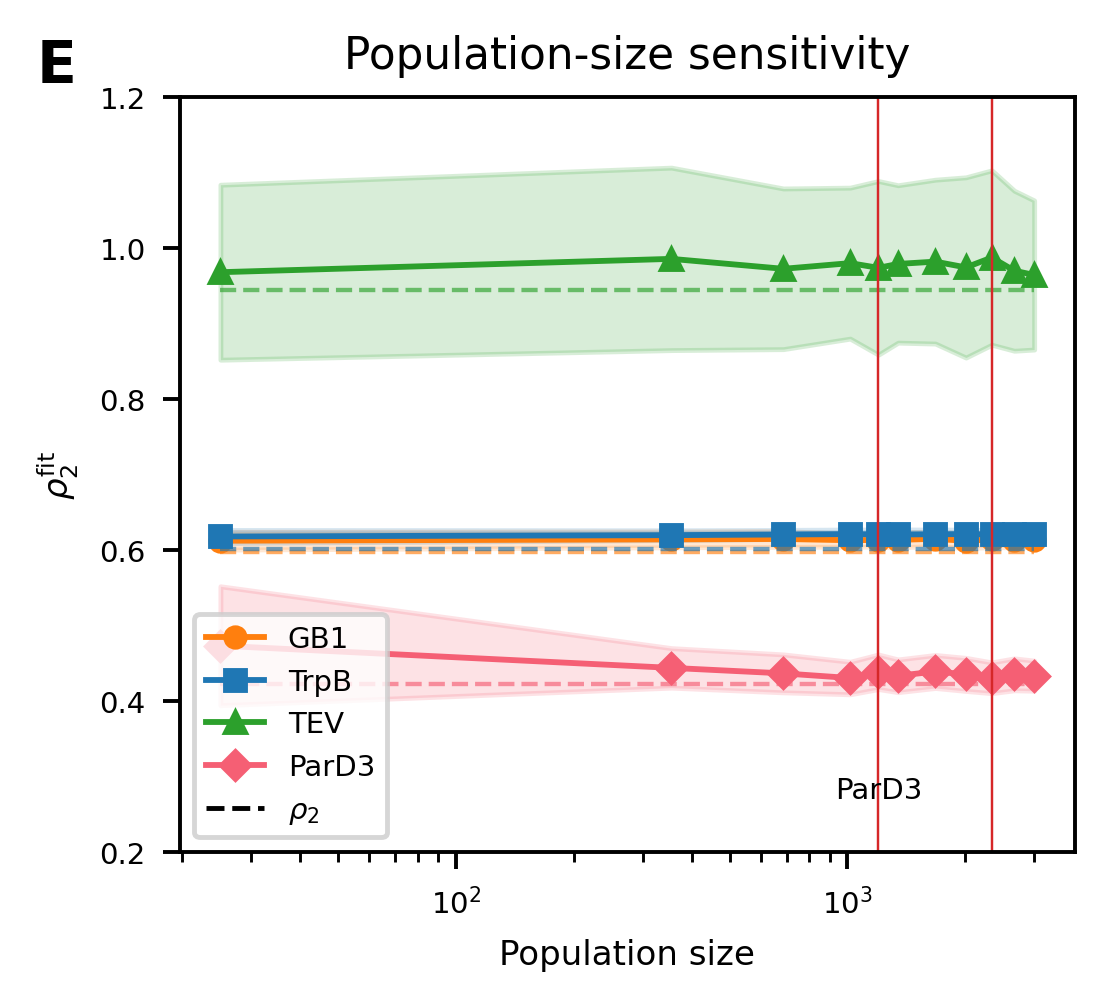

In [15]:
fig, ax = plt.subplots(figsize=(3.3, 2.8), dpi=PANEL_DPI)
for n, name in enumerate(EMPIRICAL_NAMES):
    pop_sizes = np.asarray(popsize_data[name]["pop_sizes"])
    vals = popsize_data[name]["rates"]
    means = np.asarray([np.nanmean(v) for v in vals])
    stds = np.asarray([np.nanstd(v) for v in vals])
    ax.plot(pop_sizes, means, color=colours[n], marker=markers[n], markersize=4, linewidth=1.2, label=labels[n])
    ax.fill_between(pop_sizes, means - stds, means + stds, color=colours[n], alpha=0.18)
    ax.hlines(rho2_dirichlet_vals[n], xmin=pop_sizes.min(), xmax=pop_sizes.max(), color=colours[n], linestyle="--", linewidth=0.9, alpha=0.65)
    # ax.hlines(figure_d_reference_means[name], xmin=pop_sizes.min(), xmax=pop_sizes.max(), color=colours[n], linestyle=":", linewidth=1)
for reference_popsize in np.unique(list(reference_pop_sizes.values())):
    ax.axvline(reference_popsize, color=c_reference, linewidth=0.5)
ax.set_xscale("log")
ax.set_title(r"Population-size sensitivity", fontsize=FIGURE_TITLE_SIZE)
ax.set_xlabel("Population size", fontsize=FIGURE_LABEL_SIZE)
ax.set_ylabel(r"$\rho_2^{\mathrm{fit}}$", fontsize=FIGURE_LABEL_SIZE)
ax.tick_params(axis="both", labelsize=FIGURE_TICK_SIZE)
add_panel_letter(ax, "E")
ax.text(1200, 0.3, "ParD3", fontsize=FIGURE_TICK_SIZE, va="top", ha="center")
ax.set_ylim(0.2, 1.2)
rho2_handle = Line2D([0], [0], color="black", linewidth=1, linestyle="--", label=r"$\rho_2$")
handles_legend, labels_legend = ax.get_legend_handles_labels()
handles_legend.append(rho2_handle)
labels_legend.append(r"$\rho_2$")
ax.legend(handles=handles_legend, labels=labels_legend, fontsize=FIGURE_LEGEND_SIZE, frameon=True, loc="lower left", ncol=1)
save_panel_figure(fig, "figure_4E")
plt.show()


## Panel F Processing

Fit global squared-decay estimates while varying the number of sampled generations retained from the all-start decay curves.


In [16]:
def build_generation_count_payload() -> dict[str, object]:
    """Build Figure 4F generation-count sensitivity estimates.

    Returns:
    - dict[str, object]
        Processed generation-count payload containing fitted rho2 bootstrap samples.
    """

    rng = np.random.default_rng(BOOTSTRAP_SEED)
    generation_results = {}
    for name in EMPIRICAL_NAMES:
        curves = empirical_all_curves[name]
        start_gmu = curves.mean(axis=1) ** 2
        n_steps = start_gmu.shape[-1]
        if n_steps < 40:
            raise ValueError(f"Expected at least 40 generations for Figure 4F, got {n_steps} for {name}.")
        generation_counts = np.asarray([3, 5, 10, 15, 20, 25, 30, 35, 40], dtype=int)
        landscape_rates = []
        sample_size = min(PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES if name == "ParD3" else BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, start_gmu.shape[0])
        for generation_count in tqdm(generation_counts, desc=f"{name} generation count"):
            boot_vals = []
            for _ in range(GENERATION_COUNT_BOOTSTRAPS):
                idx = rng.choice(start_gmu.shape[0], size=sample_size, replace=False)
                g_mu = start_gmu[idx, : int(generation_count)].mean(axis=0)
                boot_vals.append(fit_rho2_from_gmu(g_mu, steps=int(generation_count)))
            landscape_rates.append(finite_array(boot_vals))
        generation_results[name] = {"generation_counts": generation_counts, "rates": landscape_rates}
    return {
        "data": generation_results,
        "metadata": {"paper_reference": "Figure 4F", "description": "Global fitted rho2 over sampled generation counts."},
    }
generation_count_payload = load_or_build_processed("generation_count", build_generation_count_payload)
generation_count_data = generation_count_payload["data"]
{name: payload["generation_counts"] for name, payload in generation_count_data.items()}


Loaded figure4_generation_count_processed.pkl


{'GB1': array([ 3,  5, 10, 15, 20, 25, 30, 35, 40]),
 'TrpB': array([ 3,  5, 10, 15, 20, 25, 30, 35, 40]),
 'TEV': array([ 3,  5, 10, 15, 20, 25, 30, 35, 40]),
 'ParD3': array([ 3,  5, 10, 15, 20, 25, 30, 35, 40])}

### Panel F Individual Export
This cell saves the annotated Figure 4F subfigure after the generation-count sensitivity analysis has been processed.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


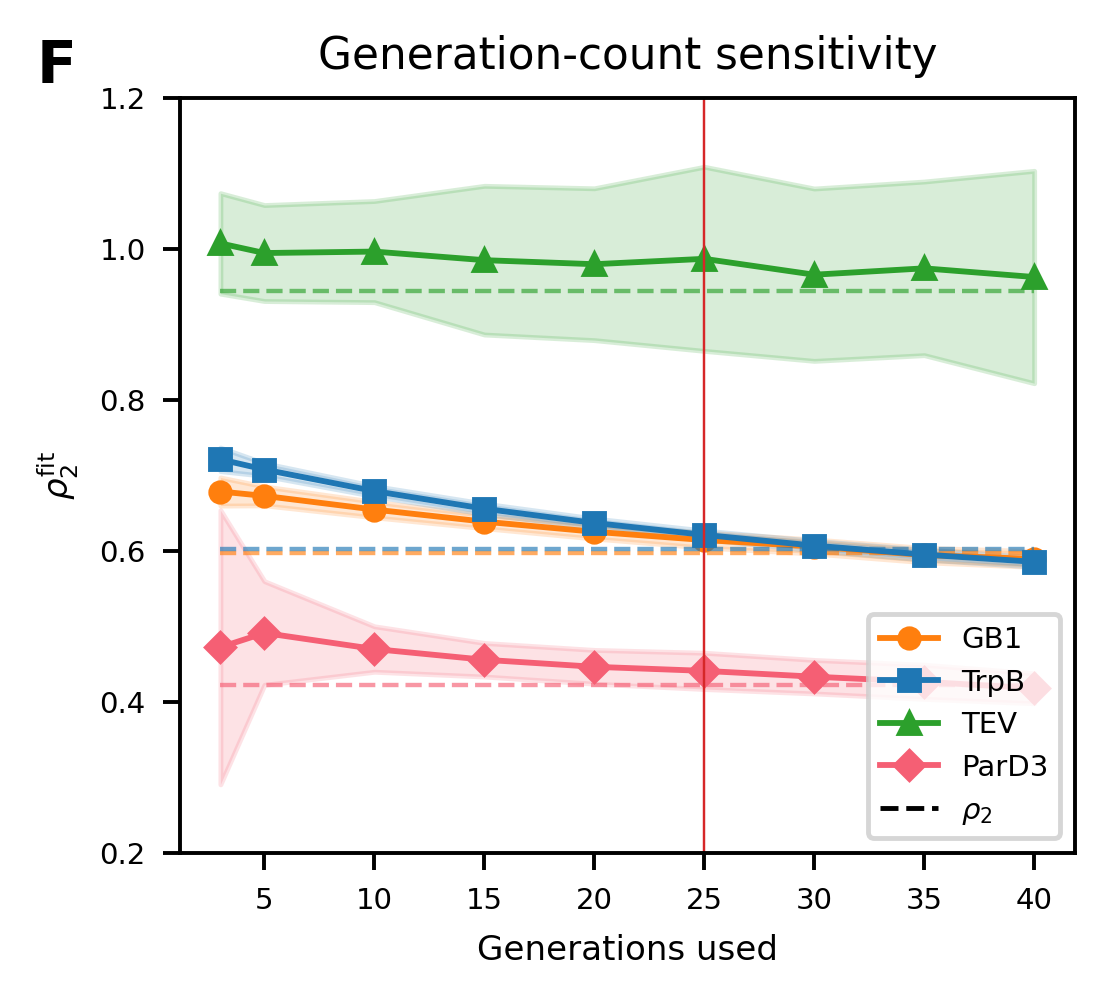

In [17]:
fig, ax = plt.subplots(figsize=(3.3, 2.8), dpi=PANEL_DPI)
for n, name in enumerate(EMPIRICAL_NAMES):
    counts = np.asarray(generation_count_data[name]["generation_counts"])
    vals = generation_count_data[name]["rates"]
    means = np.asarray([np.nanmean(v) for v in vals])
    stds = np.asarray([np.nanstd(v) for v in vals])
    ax.plot(counts, means, color=colours[n], marker=markers[n], markersize=4, linewidth=1.2, label=labels[n])
    ax.fill_between(counts, means - stds, means + stds, color=colours[n], alpha=0.18)
    ax.hlines(rho2_dirichlet_vals[n], xmin=counts.min(), xmax=counts.max(), color=colours[n], linestyle="--", linewidth=0.9, alpha=0.65)
ax.axvline(FIGURE4_DE_PROCESSING_STEPS, color=c_reference, linewidth=0.5)
ax.set_title(r"Generation-count sensitivity", fontsize=FIGURE_TITLE_SIZE)
ax.set_xlabel("Generations used", fontsize=FIGURE_LABEL_SIZE)
ax.set_ylabel(r"$\rho_2^{\mathrm{fit}}$", fontsize=FIGURE_LABEL_SIZE)
ax.tick_params(axis="both", labelsize=FIGURE_TICK_SIZE)
ax.set_ylim(0.2, 1.2)
add_panel_letter(ax, "F")
save_panel_figure(fig, "figure_4F")
rho2_handle = Line2D([0], [0], color="black", linewidth=1, linestyle="--", label=r"$\rho_2$")
handles_legend, labels_legend = ax.get_legend_handles_labels()
handles_legend.append(rho2_handle)
labels_legend.append(r"$\rho_2$")
ax.legend(handles=handles_legend, labels=labels_legend, fontsize=FIGURE_LEGEND_SIZE, frameon=True, loc="lower right", ncol=1)
plt.show()


## Panel G Processing

Compute alternative empirical ruggedness metrics on the complete landscapes for the cross-metric comparison.


In [18]:
def build_metric_comparison_payload() -> dict[str, object]:
    empirical_landscapes = [landscapes[name] for name in EMPIRICAL_NAMES]
    rho2_fit_values = []
    for name in EMPIRICAL_NAMES:
        curves = empirical_all_curves[name]
        start_gmu = curves.mean(axis=1) ** 2
        g_mu = start_gmu.mean(axis=0)
        rho2_fit_values.append(fit_rho2_from_gmu(g_mu, steps=g_mu.shape[-1]))

    rho2_dirichlet_values = [get_dirichlet_metric(landscape, on_gpu=False) for landscape in empirical_landscapes]
    roughness_values = [roughness_to_slope(landscape) for landscape in empirical_landscapes]
    fourier_r2_values = [landscape_r2(landscape) for landscape in empirical_landscapes]
    entropy_values = [get_spectral_entropy(landscape, on_gpu=False) for landscape in empirical_landscapes]
    starting_points = [np.array([3, 17, 0, 3]), np.array([3, 8, 3, 18]), np.array([19, 17, 11, 18]), np.array([17, 12, 16])]
    epistasis_raw = [local_epistasis(landscape, start) for landscape, start in zip(empirical_landscapes, starting_points)]
    epistasis_values = [
        value.get("simple_sign_episasis", 0) + value.get("reciprocal_sign_epistasis", 0)
        if isinstance(value, dict)
        else value
        for value in epistasis_raw
    ]
    paths_to_max_values = [get_mean_paths_to_max(landscape, norm=False) for landscape in empirical_landscapes]
    paths_to_max_values[3] = paths_to_max_values[3] * (max_possible_paths(landscapes["GB1"].shape) / max_possible_paths(landscapes["ParD3"].shape))
    closest_max_values = [1 / find_distance_to_closest_max(landscape) for landscape in empirical_landscapes]

    return {
        "data": {
            "rho_2_fit": np.asarray(rho2_fit_values),
            "rho_2_dirichlet": np.asarray(rho2_dirichlet_values),
            "roughness_to_slope": np.asarray(roughness_values),
            "fourier_r2": np.asarray(fourier_r2_values),
            "spectral_entropy": np.asarray(entropy_values),
            "paths_to_max": np.asarray(paths_to_max_values),
            "closest_max": np.asarray(closest_max_values),
            "local_epistasis": np.asarray(epistasis_values),
        },
        "metadata": {"paper_reference": "Figure 4G", "description": "Empirical ruggedness metric comparison."},
    }

metric_payload = load_or_build_processed("metric_comparison", build_metric_comparison_payload)
metric_data = metric_payload["data"]
metric_data.keys()


Loaded figure4_metric_comparison_processed.pkl


dict_keys(['rho_2_fit', 'rho_2_dirichlet', 'roughness_to_slope', 'fourier_r2', 'spectral_entropy', 'paths_to_max', 'closest_max', 'local_epistasis'])

### Panel G Individual Export
This cell saves the annotated Figure 4G subfigure after the empirical metric comparison has been processed.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


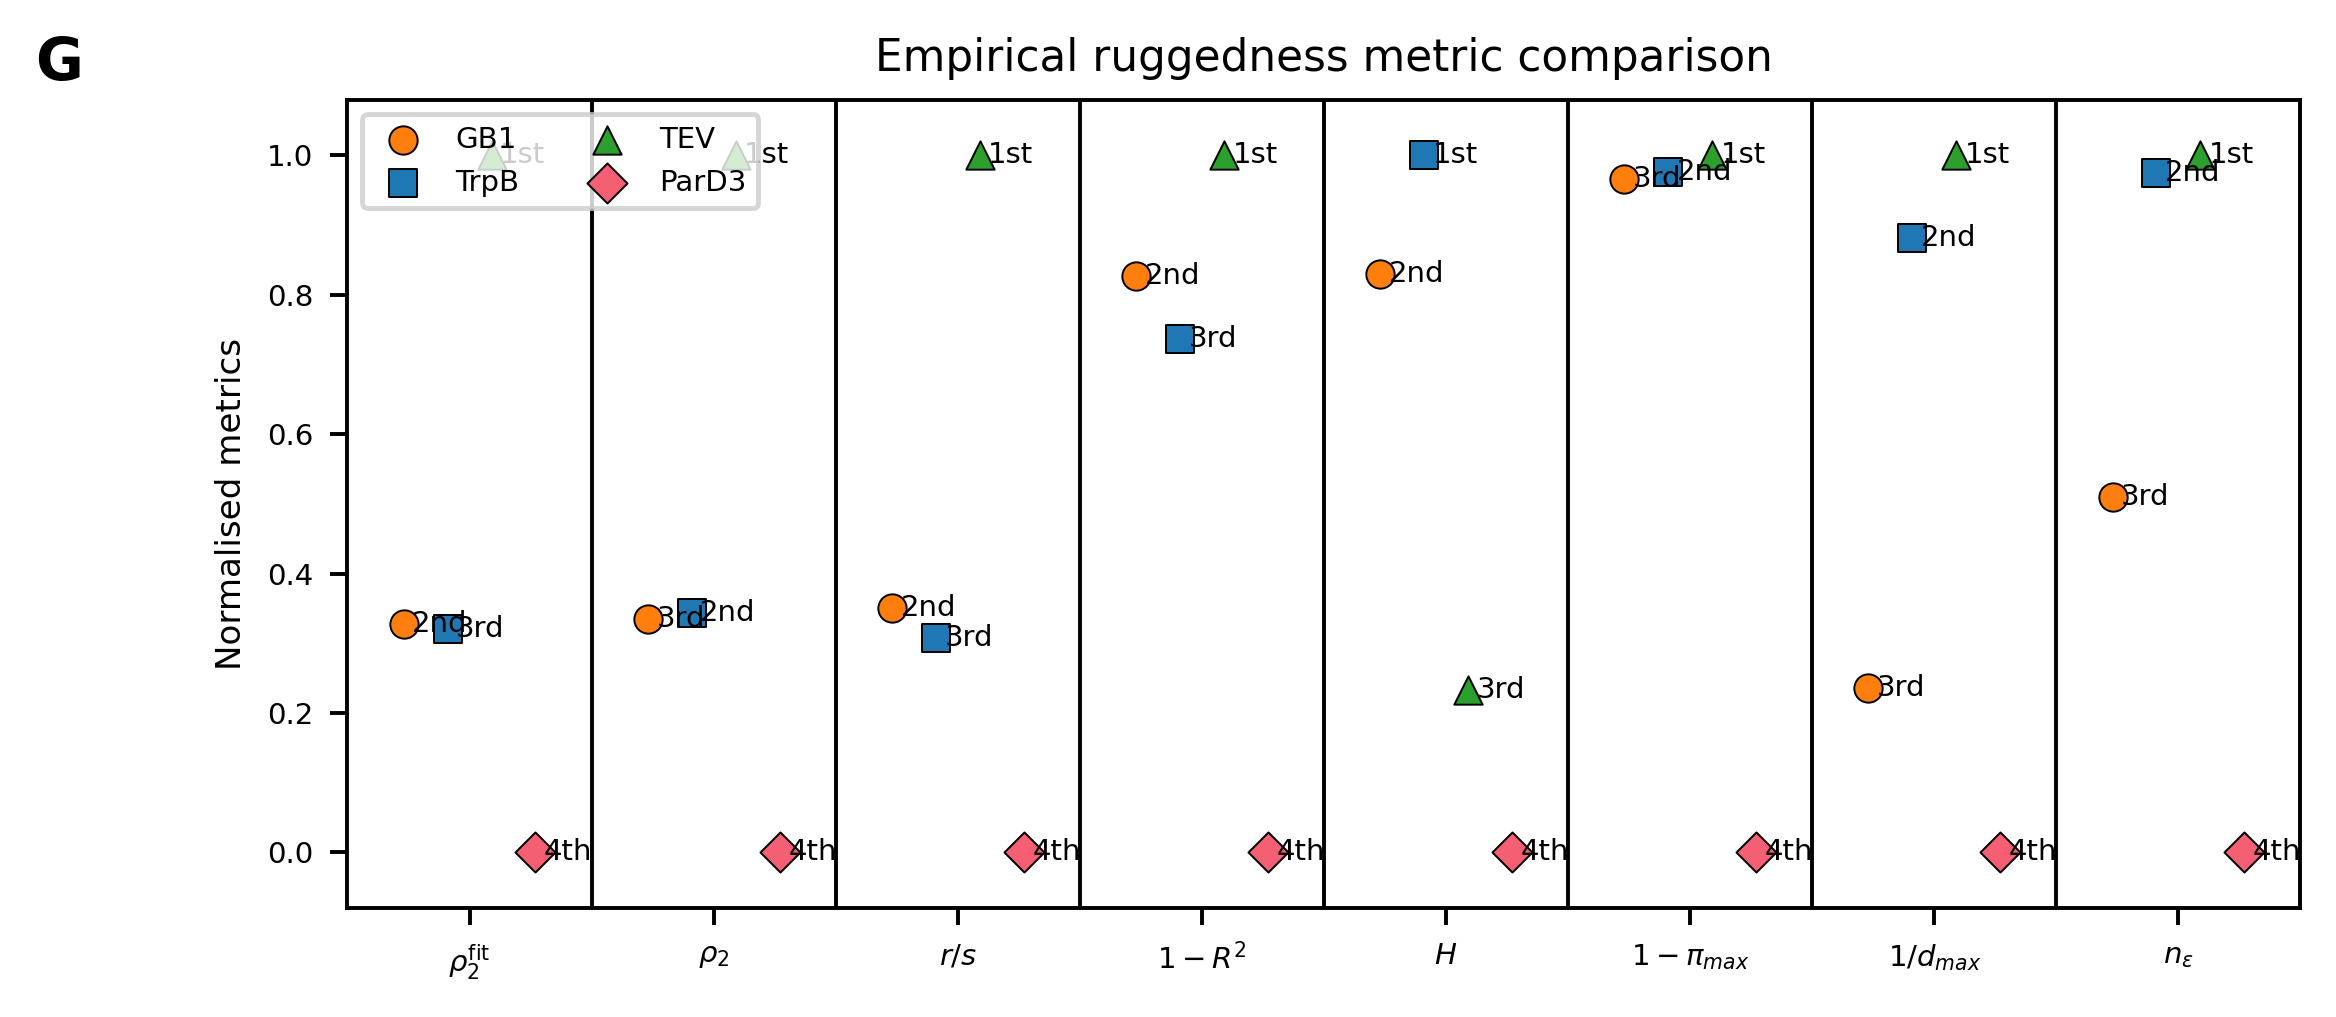

In [19]:
metric_plot_specs = [
    ("rho_2_fit", r"$\rho^{\mathrm{fit}}_2$", False),
    ("rho_2_dirichlet", r"$\rho_2$", False),
    ("roughness_to_slope", r"$r/s$", False),
    ("fourier_r2", r"$1 - R^2$", True),
    ("spectral_entropy", r"$H$", False),
    ("paths_to_max", r"$1 - \pi_{max}$", True),
    ("closest_max", r"$1/d_{max}$", False),
    ("local_epistasis", r"$n_{\epsilon}$", False),
]
ordinal_labels = np.asarray(["1st", "2nd", "3rd", "4th"])
x_offsets = np.linspace(-0.27, 0.27, len(labels))
fig, ax = plt.subplots(figsize=(7.2, 3.0), dpi=PANEL_DPI)
for metric_index, (metric_key, _, invert) in enumerate(metric_plot_specs):
    values = np.asarray(metric_data[metric_key], dtype=float)
    span = np.nanmax(values) - np.nanmin(values)
    normalized = (values - np.nanmin(values)) / (span + EPS)
    if invert:
        normalized = 1 - normalized
    metric_ranks = np.empty(len(normalized), dtype=int)
    metric_ranks[np.argsort(-normalized)] = np.arange(len(normalized))
    for landscape_index, value in enumerate(normalized):
        ax.scatter(
            metric_index + x_offsets[landscape_index],
            value,
            color=colours[landscape_index],
            marker=markers[landscape_index],
            s=34,
            edgecolors="black",
            linewidth=0.4,
            label=labels[landscape_index] if metric_index == 0 else None,
        )
        ax.text(
            metric_index + x_offsets[landscape_index] + 0.035,
            value,
            ordinal_labels[metric_ranks[landscape_index]],
            fontsize=FIGURE_TICK_SIZE,
            va="center",
            ha="left",
        )
for separator in np.arange(0.5, len(metric_plot_specs) - 0.5, 1):
    ax.axvline(separator, color="black", linewidth=0.8, alpha=1)
ax.set_xticks(np.arange(len(metric_plot_specs)))
ax.set_xticklabels([label for _, label, _ in metric_plot_specs], rotation=0, ha="center", fontsize=FIGURE_TICK_SIZE)
ax.set_ylabel("Normalised metrics", fontsize=FIGURE_LABEL_SIZE)
ax.set_ylim(-0.08, 1.08)
ax.set_xlim(-0.5, 7.5)
ax.set_title("Empirical ruggedness metric comparison", fontsize=FIGURE_TITLE_SIZE)
ax.tick_params(axis="y", labelsize=FIGURE_TICK_SIZE)
ax.legend(fontsize=FIGURE_LEGEND_SIZE, frameon=True, ncol=2, loc="upper left")
add_panel_letter(ax, "G")
save_panel_figure(fig, "figure_4G")
plt.show()


## Visualisation

Compose Figure 4 panels A-G from the processed payloads. The output uses the paper's empirical landscape colour order: GB1, TrpB, TEV, ParD3.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


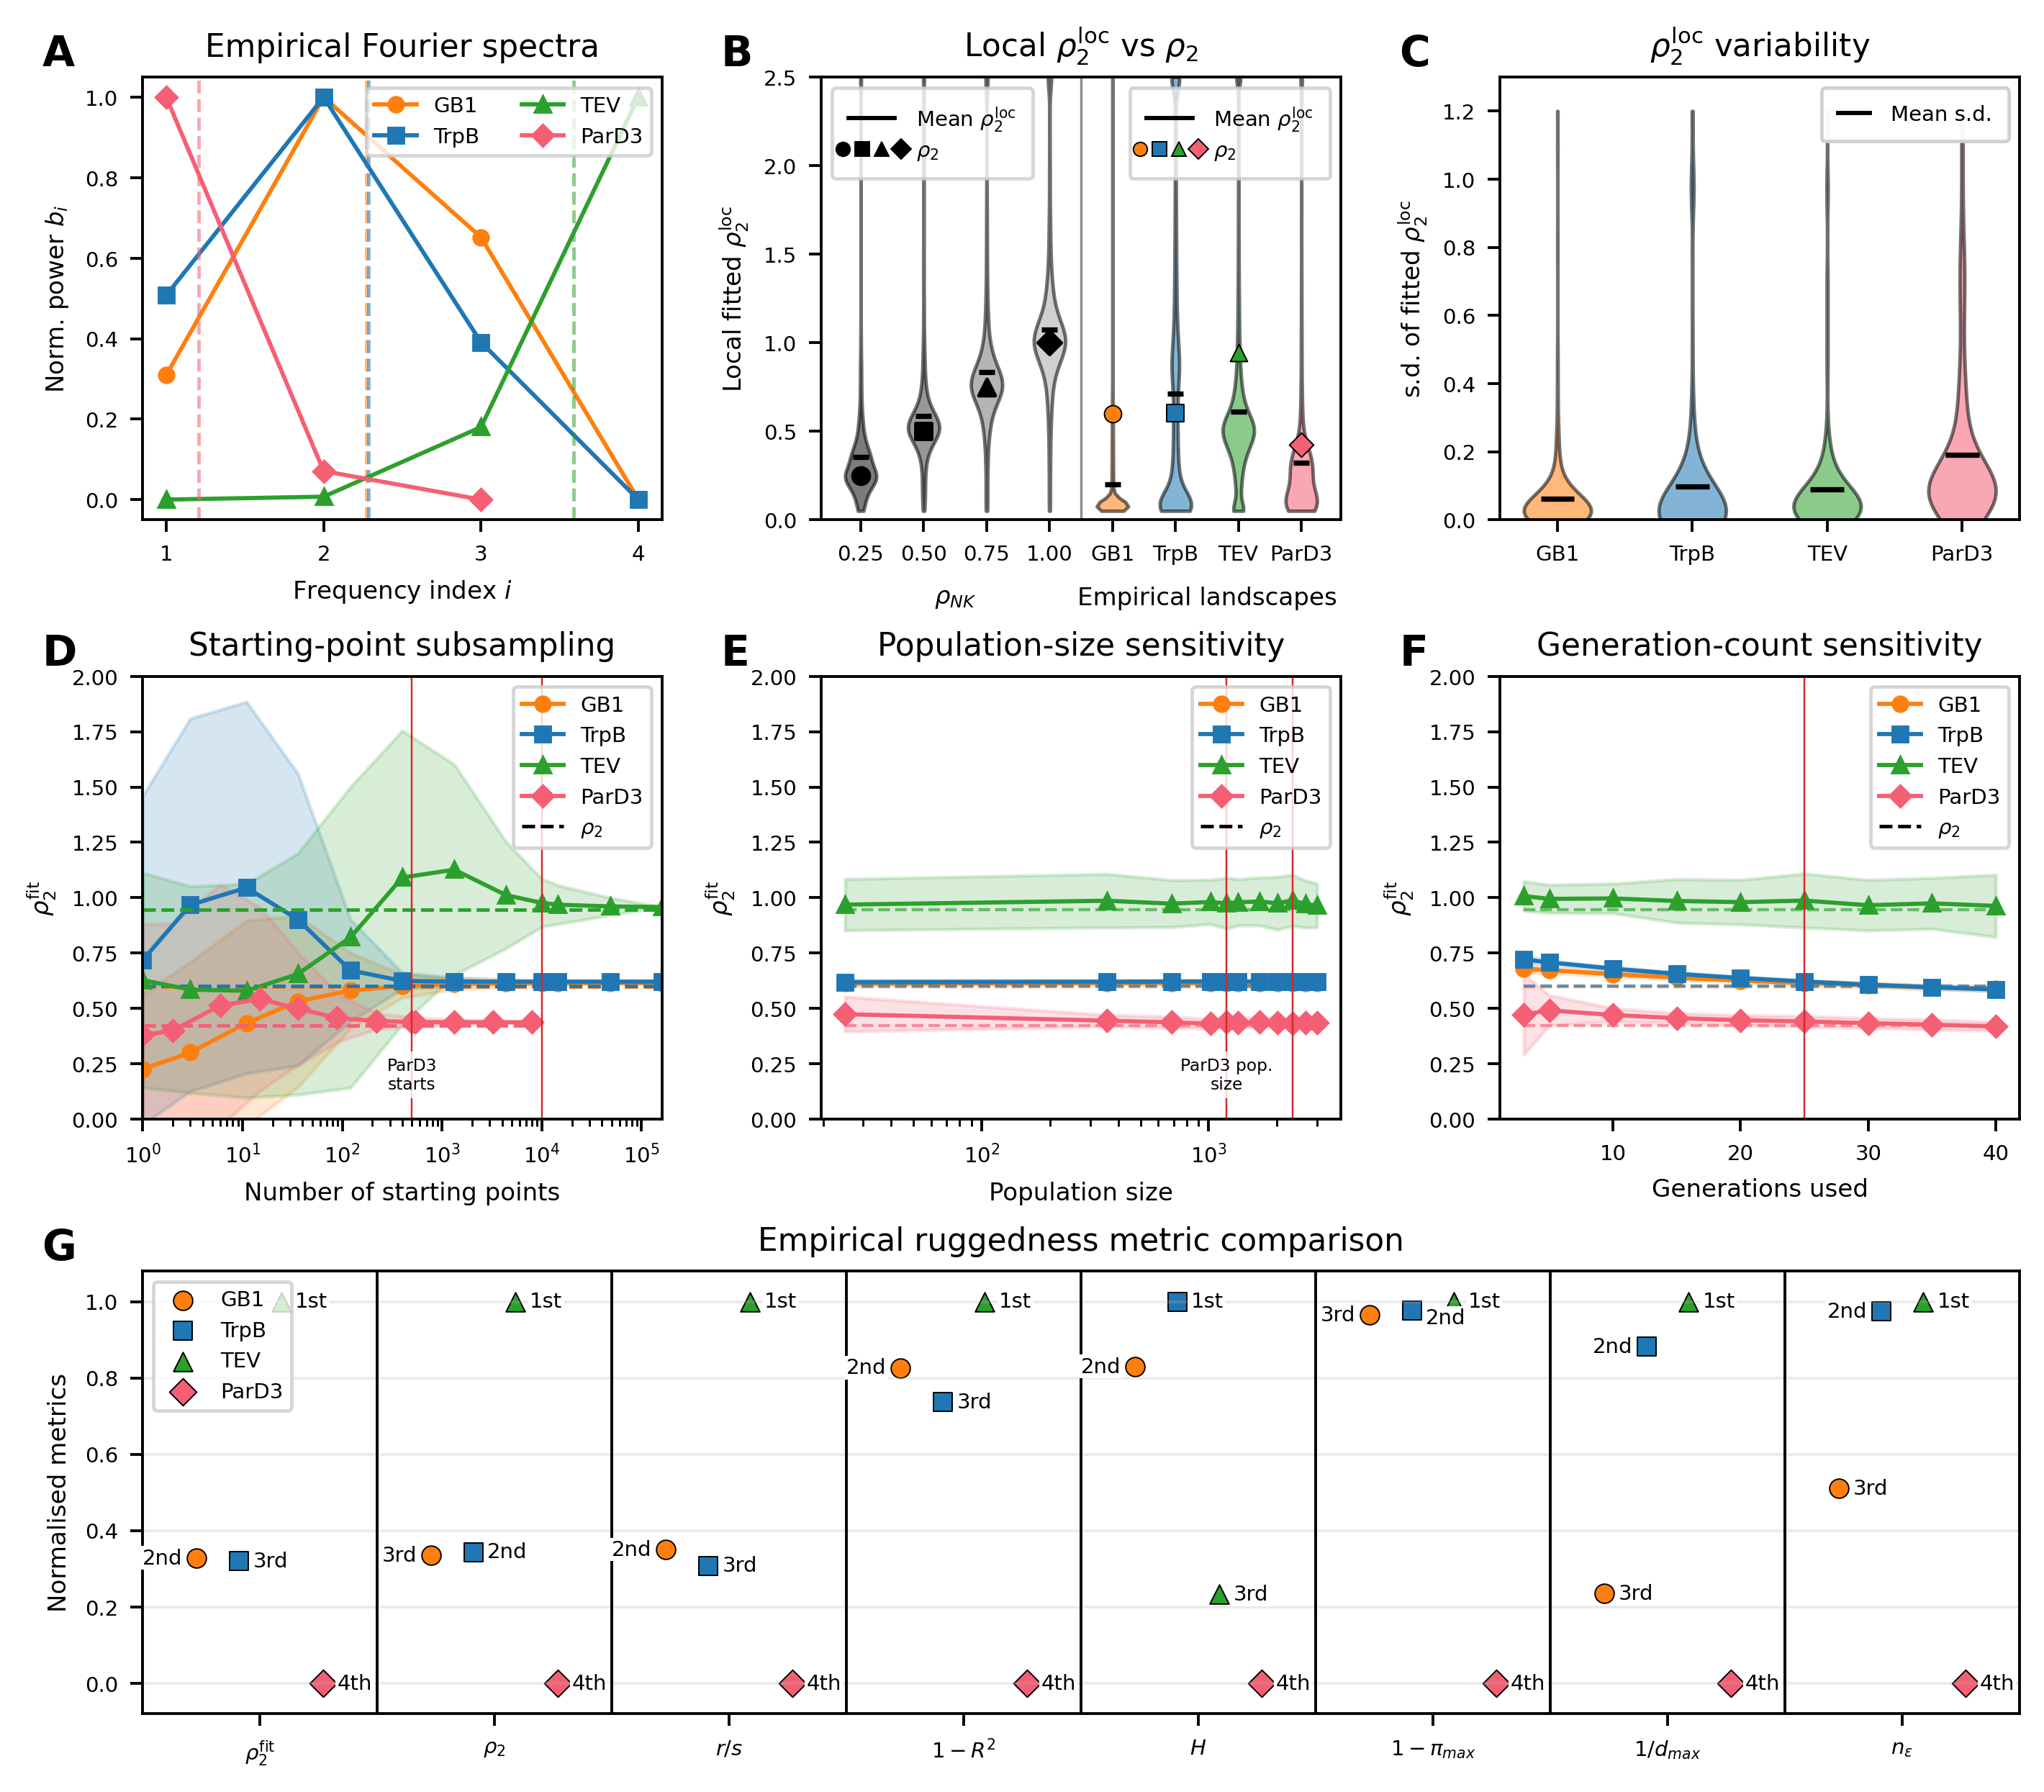

In [ ]:
# Figure styling.
labelsize = FIGURE_LABEL_SIZE
ticksize = FIGURE_TICK_SIZE
titlesize = FIGURE_TITLE_SIZE
legendsize = FIGURE_LEGEND_SIZE
dpi = PANEL_DPI
plt.rcParams["font.family"] = "DejaVu Sans"

panel_letter_offsets = (-0.05, 0.025)

fig = plt.figure(figsize=(8, 7), dpi=dpi, constrained_layout=True)
ax.set_ylim(-0.08, 1.08)
gs = GridSpec(3, 3, figure=fig, height_ratios=[1.0, 1.0, 1])
axes = {
    "A": fig.add_subplot(gs[0, 0]),
    "B": fig.add_subplot(gs[0, 1]),
    "C": fig.add_subplot(gs[0, 2]),
    "D": fig.add_subplot(gs[1, 0]),
    "E": fig.add_subplot(gs[1, 1]),
    "F": fig.add_subplot(gs[1, 2]),
    "G": fig.add_subplot(gs[2, :]),
}

# Panel A: Fourier spectra.
ax = axes["A"]
for n, spectrum in enumerate(spectra_data["spectra"]):
    nonconstant = np.asarray(spectrum, dtype=float)[1:]
    spectrum_norm = (nonconstant - nonconstant.min()) / (nonconstant.max() - nonconstant.min() + EPS)
    indexes = np.arange(1, len(nonconstant) + 1)
    ax.plot(indexes, spectrum_norm, marker=markers[n], markersize=4, linewidth=1.2, color=colours[n], label=labels[n])
    ax.axvline(spectra_data["frequency_centroids"][n], color=colours[n], linestyle="--", alpha=0.55, linewidth=1)
ax.set_title("Empirical Fourier spectra", fontsize=titlesize)
ax.set_xlabel(r"Frequency index $i$", fontsize=labelsize)
ax.set_ylabel(r"Norm. power $b_i$", fontsize=labelsize)
ax.set_xticks([1, 2, 3, 4])
ax.tick_params(axis="both", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=True, loc="upper right", ncol=2)

# Panel B: NK and empirical local fitted rho2 distributions.
ax = axes["B"]
nk_local_items = [(float(rho), finite_array(values)) for rho, values in sorted(nk_local_rhos.items())]
empirical_local_items = [(name, finite_array(empirical_local_rhos[name])) for name in EMPIRICAL_NAMES]
local_data = [values for _, values in nk_local_items] + [values for _, values in empirical_local_items]
positions = np.arange(1, len(local_data) + 1)
vp = ax.violinplot(local_data, positions=positions, showmeans=True, showextrema=False)
body_colours = nk_colours[: len(nk_local_items)] + colours
for body, color in zip(vp["bodies"], body_colours):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.55)
vp["cmeans"].set_color("black")
for idx, (rho_nk, _) in enumerate(nk_local_items, start=1):
    ax.scatter(idx, rho_nk, color="black", marker=nk_markers[idx - 1], s=22, zorder=3)
for idx, value in enumerate(rho2_dirichlet_vals, start=len(nk_local_items) + 1):
    empirical_index = idx - len(nk_local_items) - 1
    ax.scatter(idx, value, color=colours[empirical_index], marker=markers[empirical_index], s=24, edgecolors="black", linewidth=0.4, zorder=3)
group_boundary = len(nk_local_items) + 0.5
ax.axvline(group_boundary, color="black", linewidth=0.7, alpha=0.45)
xtick_labels = [rf"{rho:.2f}" for rho, _ in nk_local_items] + labels
ax.set_xticks(positions)
ax.set_xticklabels(xtick_labels, rotation=0, ha="center", fontsize=ticksize)
ax.text(np.mean(positions[: len(nk_local_items)]), -0.15, r"$\rho_{NK}$", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=labelsize)
ax.text(np.mean(positions[len(nk_local_items) :]), -0.15, "Empirical landscapes", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=labelsize)
ax.set_ylabel(r"Local fitted $\rho^{\mathrm{loc}}_2$", fontsize=labelsize)
ax.set_title(r"Local $\rho^{\mathrm{loc}}_2$ vs $\rho_2$", fontsize=titlesize)
ax.tick_params(axis="y", labelsize=ticksize)
ax.set_ylim(0, 2.5)
nk_rho_handles = tuple(
    Line2D([0], [0], marker=marker, linestyle="None", markerfacecolor="black", markeredgecolor="black", markeredgewidth=0.4, markersize=4)
    for marker in nk_markers[: len(nk_local_items)]
)
mean_rho_handle = Line2D([0], [0], color="black", linewidth=1.2, label=r"Mean $\rho^{\mathrm{loc}}_2$")
rho2_handles = tuple(
    Line2D([0], [0], marker=marker, linestyle="None", markerfacecolor=color, markeredgecolor="black", markeredgewidth=0.4, markersize=4)
    for marker, color in zip(markers, colours)
)
nk_legend = ax.legend(
    handles=[mean_rho_handle, nk_rho_handles],
    labels=[r"Mean $\rho^{\mathrm{loc}}_2$", r"$\rho_2$"],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=1.5)},
    handlelength=2.2,
    handletextpad=1,
    fontsize=legendsize,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.35,
    loc="upper left",
)
ax.add_artist(nk_legend)
ax.legend(
    handles=[mean_rho_handle, rho2_handles],
    labels=[r"Mean $\rho^{\mathrm{loc}}_2$", r"$\rho_2$"],
    handler_map={tuple: HandlerTuple(ndivide=4, pad=1.5)},
    handlelength=2.2,
    handletextpad=1,
    fontsize=legendsize,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.35,
    loc="upper right",
)

# Panel C: replicate variability.
ax = axes["C"]
variability_data = [finite_array(replicate_variability[name]) for name in EMPIRICAL_NAMES]
vp = ax.violinplot(variability_data, showmeans=True, showextrema=False)
for body, color in zip(vp["bodies"], colours):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.55)
vp["cmeans"].set_color("black")
ax.set_xticks(np.arange(1, 5))
ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=ticksize)
ax.set_ylabel(r"s.d. of fitted $\rho^{\mathrm{loc}}_2$", fontsize=labelsize)
ax.set_title(r"$\rho^{\mathrm{loc}}_2$ variability", fontsize=titlesize)
ax.tick_params(axis="y", labelsize=ticksize)
rhovar_legend = ax.legend(
    handles=[Line2D([0], [0], color="black", linewidth=1.2, label=r"Mean s.d.")],
    labels=[r"Mean s.d."],
    handler_map={tuple: HandlerTuple(ndivide=None, pad=1.5)},
    handlelength=1.5,
    handletextpad=1,
    fontsize=legendsize,
    frameon=True,
    borderpad=0.8,
    labelspacing=0.35,
    loc="upper right",
)
ax.set_ylim(0, 1.3)
ax.add_artist(rhovar_legend)

# Panel D: subsampling trajectory counts.
ax = axes["D"]
for n, name in enumerate(EMPIRICAL_NAMES):
    counts = np.asarray(trajectory_counts[name])
    vals = subsampling_data[name]
    means = np.asarray([np.nanmean(v) for v in vals])
    stds = np.asarray([np.nanstd(v) for v in vals])
    ax.plot(counts, means, color=colours[n], marker=markers[n], markersize=4, linewidth=1.2, label=labels[n])
    ax.fill_between(counts, means - stds, means + stds, color=colours[n], alpha=0.18)
    ax.hlines(rho2_dirichlet_vals[n], xmin=counts.min(), xmax=counts.max(), color=colours[n], linestyle="--", linewidth=1)
ax.axvline(BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, color=c_reference, linewidth=0.5)
ax.axvline(PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, color=c_reference, linewidth=0.5)
ax.set_xscale("log")
ax.set_title("Starting-point subsampling", fontsize=titlesize)
ax.set_xlabel("Number of starting points", fontsize=labelsize)
ax.set_ylabel(r"$\rho_2^{\mathrm{fit}}$", fontsize=labelsize)
ax.set_ylim(0, 2)
ax.set_xlim(1, 160000)
ax.tick_params(axis="both", labelsize=ticksize)
ax.text(PARD3_BOOTSTRAP_STARTS_FOR_GLOBAL_ESTIMATES, 0.28, "ParD3\nstarts", fontsize=ticksize*0.8, va="top", ha="center", bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
rho2_handle = Line2D([0], [0], color="black", linewidth=1, linestyle="--", label=r"$\rho_2$")
handles_legend, labels_legend = ax.get_legend_handles_labels()
handles_legend.append(rho2_handle)
labels_legend.append(r"$\rho_2$")
ax.legend(handles=handles_legend, labels=labels_legend, fontsize=legendsize, frameon=True, loc="upper right", ncol=1)

# Panel E: population size.
ax = axes["E"]
for n, name in enumerate(EMPIRICAL_NAMES):
    pop_sizes = np.asarray(popsize_data[name]["pop_sizes"])
    vals = popsize_data[name]["rates"]
    means = np.asarray([np.nanmean(v) for v in vals])
    stds = np.asarray([np.nanstd(v) for v in vals])
    ax.plot(pop_sizes, means, color=colours[n], marker=markers[n], markersize=4, linewidth=1.2, label=labels[n])
    ax.fill_between(pop_sizes, means - stds, means + stds, color=colours[n], alpha=0.18)
    ax.hlines(rho2_dirichlet_vals[n], xmin=pop_sizes.min(), xmax=pop_sizes.max(), color=colours[n], linestyle="--", linewidth=0.9, alpha=0.65)
for reference_popsize in np.unique(list(reference_pop_sizes.values())):
    ax.axvline(reference_popsize, color=c_reference, linewidth=0.5)
ax.set_xscale("log")
ax.set_title("Population-size sensitivity", fontsize=titlesize)
ax.set_xlabel("Population size", fontsize=labelsize)
ax.set_ylabel(r"$\rho_2^{\mathrm{fit}}$", fontsize=labelsize)
ax.tick_params(axis="both", labelsize=ticksize)
ax.text(1200, 0.28, "ParD3 pop.\nsize", fontsize=ticksize*0.8, va="top", ha="center", bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax.set_ylim(0, 2)
rho2_handle = Line2D([0], [0], color="black", linewidth=1, linestyle="--", label=r"$\rho_2$")
handles_legend, labels_legend = ax.get_legend_handles_labels()
handles_legend.append(rho2_handle)
labels_legend.append(r"$\rho_2$")
ax.legend(handles=handles_legend, labels=labels_legend, fontsize=legendsize, frameon=True, loc="upper right", ncol=1)

# Panel F: sampled generation count.
ax = axes["F"]
for n, name in enumerate(EMPIRICAL_NAMES):
    counts = np.asarray(generation_count_data[name]["generation_counts"])
    vals = generation_count_data[name]["rates"]
    means = np.asarray([np.nanmean(v) for v in vals])
    stds = np.asarray([np.nanstd(v) for v in vals])
    ax.plot(counts, means, color=colours[n], marker=markers[n], markersize=4, linewidth=1.2, label=labels[n])
    ax.fill_between(counts, means - stds, means + stds, color=colours[n], alpha=0.18)
    ax.hlines(rho2_dirichlet_vals[n], xmin=counts.min(), xmax=counts.max(), color=colours[n], linestyle="--", linewidth=0.9, alpha=0.65)
ax.axvline(FIGURE4_DE_PROCESSING_STEPS, color=c_reference, linewidth=0.5)
ax.set_title("Generation-count sensitivity", fontsize=titlesize)
ax.set_xlabel("Generations used", fontsize=labelsize)
ax.set_ylabel(r"$\rho_2^{\mathrm{fit}}$", fontsize=labelsize)
ax.tick_params(axis="both", labelsize=ticksize)
ax.set_ylim(0, 2)
rho2_handle = Line2D([0], [0], color="black", linewidth=1, linestyle="--", label=r"$\rho_2$")
handles_legend, labels_legend = ax.get_legend_handles_labels()
handles_legend.append(rho2_handle)
labels_legend.append(r"$\rho_2$")
ax.legend(handles=handles_legend, labels=labels_legend, fontsize=legendsize, frameon=True, loc="upper right", ncol=1)

# Panel G: metric comparison.
ax = axes["G"]
metric_plot_specs = [
    ("rho_2_fit", r"$\rho^{\mathrm{fit}}_2$", False),
    ("rho_2_dirichlet", r"$\rho_2$", False),
    ("roughness_to_slope", r"$r/s$", False),
    ("fourier_r2", r"$1 - R^2$", True),
    ("spectral_entropy", r"$H$", False),
    ("paths_to_max", r"$1 - \pi_{max}$", True),
    ("closest_max", r"$1/d_{max}$", False),
    ("local_epistasis", r"$n_{\epsilon}$", False),
]
ordinal_labels = np.asarray(["1st", "2nd", "3rd", "4th"])
x_offsets = np.linspace(-0.27, 0.27, len(labels))
for metric_index, (metric_key, _, invert) in enumerate(metric_plot_specs):
    values = np.asarray(metric_data[metric_key], dtype=float)
    span = np.nanmax(values) - np.nanmin(values)
    normalized = (values - np.nanmin(values)) / (span + EPS)
    if invert:
        normalized = 1 - normalized
    metric_ranks = np.empty(len(normalized), dtype=int)
    metric_ranks[np.argsort(-normalized)] = np.arange(len(normalized))
    for landscape_index, value in enumerate(normalized):
        ax.scatter(metric_index + x_offsets[landscape_index], value, color=colours[landscape_index], marker=markers[landscape_index], s=30, edgecolors="black", linewidth=0.4, label=labels[landscape_index] if metric_index == 0 else None)
        if ordinal_labels[metric_ranks[landscape_index]] == "2nd" and metric_key not in ["rho_2_dirichlet", "paths_to_max"]:
            ax.text(metric_index + x_offsets[landscape_index] - 0.06, value, ordinal_labels[metric_ranks[landscape_index]], bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=0.5), fontsize=ticksize, va="center", ha="right")
        elif ordinal_labels[metric_ranks[landscape_index]] == "3rd" and metric_key in ["rho_2_dirichlet", "paths_to_max"]:
            ax.text(metric_index + x_offsets[landscape_index] - 0.06, value, ordinal_labels[metric_ranks[landscape_index]], bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=0.5), fontsize=ticksize, va="center", ha="right")
        elif ordinal_labels[metric_ranks[landscape_index]] == "2nd" and metric_key in ["paths_to_max"]:
            ax.text(metric_index + x_offsets[landscape_index] + 0.06, value - 0.02, ordinal_labels[metric_ranks[landscape_index]], bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=0.5), fontsize=ticksize, va="center", ha="left")
        else:
            ax.text(metric_index + x_offsets[landscape_index] + 0.06, value, ordinal_labels[metric_ranks[landscape_index]], bbox=dict(facecolor="white", edgecolor="none", alpha=1, pad=0.5), fontsize=ticksize, va="center", ha="left")
for separator in np.arange(0.5, len(metric_plot_specs) - 0.5, 1):
    ax.axvline(separator, color="black", linewidth=0.8, alpha=1)
ax.set_xticks(np.arange(len(metric_plot_specs)))
ax.set_xticklabels([label for _, label, _ in metric_plot_specs], rotation=0, ha="center", fontsize=ticksize)
ax.set_ylabel("Normalised metrics", fontsize=labelsize)
ax.set_ylim(-0.08, 1.08)
ax.set_xlim(-0.5,7.5)
ax.set_title("Empirical ruggedness metric comparison", fontsize=titlesize)
ax.tick_params(axis="y", labelsize=ticksize)
ax.legend(fontsize=legendsize, frameon=True, ncol=1, loc="upper left")
ax.grid(True, axis="y", alpha=0.25)

fig.canvas.draw()
for letter, panel_ax in axes.items():
    bbox = panel_ax.get_position()
    fig.text(
        bbox.x0 + panel_letter_offsets[0],
        bbox.y1 + panel_letter_offsets[1],
        letter,
        fontsize=PANEL_LETTER_SIZE,
        fontweight="bold",
        va="top",
        ha="left",
    )

if SAVE_FIGURES:
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"figure_4.{figure_type}", dpi=dpi, bbox_inches="tight", pad_inches=0)
plt.show()
